# Data Loading & Manipulation

In [1]:
import polars as pl
import pathlib
from typing import List, Set

# -------------------------------
# CONFIG
# -------------------------------
DATA_DIR = pathlib.Path("./") 

FILES = {
    "sp500": "1_sp500_new_csv.csv",
    "ratios": "2_financial_ratios_csv.csv",
    "taq": "3_NYSE_Trades_and_Quotes_CSV.csv",
    "indices": "4_index_csv.csv",
}

def extract_bloomberg_tickers(file_path: pathlib.Path) -> List[str]:
    with open(file_path, 'r') as f:
        lines = f.read().splitlines()
    ticker_line = lines[3]  # row 4 (0-based index 3)
    items = ticker_line.split(',')
    tickers = []
    for item in items:
        item = item.strip()
        if any(s in item for s in ['Equity', 'Index', 'Curncy']):
            parts = item.split()
            if parts and parts[0].isalnum() and len(parts[0]) <= 10:
                tickers.append(parts[0])
    return tickers

def extract_bloomberg_fields(file_path: pathlib.Path) -> List[str]:
    with open(file_path, 'r') as f:
        lines = f.read().splitlines()
    field_line = lines[5] 
    fields = field_line.split(',')[1:]  
    unique_fields = []
    seen = set()
    for f in fields:
        f = f.strip()
        if f and f not in seen:
            unique_fields.append(f)
            seen.add(f)
    return unique_fields

# ===============================
# LOAD SP500 BLOOMBERG
# ===============================
print("Loading SP500 Bloomberg panel...")
sp500_tickers = extract_bloomberg_tickers(DATA_DIR / FILES["sp500"])
sp500_fields = extract_bloomberg_fields(DATA_DIR / FILES["sp500"])
print(f"Extracted {len(sp500_tickers)} tickers: {sp500_tickers[:10]}...")
print(f"Fields per ticker: {sp500_fields}")

# Construct column names
column_names = ["date"]
for t in sp500_tickers:
    for f in sp500_fields:
        column_names.append(f"{t}_{f}")

# Load data (skip 6 header rows, no built-in header)
df_sp500 = pl.read_csv(
    DATA_DIR / FILES["sp500"],
    skip_rows=6,
    has_header=False,
    new_columns=column_names,
    try_parse_dates=True,
    ignore_errors=True,
    infer_schema_length=10000,
    null_values=["#N/A N/A", "#NAME?", "NA"]
)

print("SP500 head:")
print(df_sp500.head(5))

# Date range
sp500_dates = df_sp500["date"].drop_nulls()
sp500_min = sp500_dates.min()
sp500_max = sp500_dates.max()
print(f"SP500 date range: {sp500_min} → {sp500_max}")

# ===============================
# LOAD WRDS RATIOS
# ===============================
print("\nLoading WRDS financial ratios...")
df_ratios = pl.read_csv(DATA_DIR / FILES["ratios"], infer_schema_length=10000, ignore_errors=True)
print("Ratios head:")
print(df_ratios.head(5))

ratios_tickers: Set[str] = set(
    df_ratios["TICKER"].drop_nulls().str.strip_chars().unique().to_list()
)
print(f"Unique tickers in ratios: {len(ratios_tickers)} (sample: {list(ratios_tickers)[:10]}...)")

# Date range (try public_date, fallback to adate or qdate)
date_cols = [col for col in ["public_date", "adate", "qdate"] if col in df_ratios.columns]
if date_cols:
    ratios_dates = df_ratios.select(pl.col(date_cols[0]).str.to_date(strict=False)).to_series().drop_nulls()
    ratios_min = ratios_dates.min()
    ratios_max = ratios_dates.max()
    print(f"Ratios date range ({date_cols[0]}): {ratios_min} → {ratios_max}")
else:
    print("No date columns found in ratios")
    ratios_min, ratios_max = None, None

# ===============================
# LOAD NYSE TAQ
# ===============================
print("\nLoading NYSE TAQ (nuclear safe)...")
# Force all as string to avoid parse errors
schema_sample = pl.read_csv(DATA_DIR / FILES["taq"], n_rows=0)
schema_override = {col: pl.Utf8 for col in schema_sample.columns}

df_taq = pl.read_csv(
    DATA_DIR / FILES["taq"],
    schema_overrides=schema_override,
    low_memory=True,
    ignore_errors=True
)

print("TAQ head:")
print(df_taq.head(5))

taq_tickers: Set[str] = set(
    df_taq["symbol"].drop_nulls().unique().to_list()
)
print(f"Unique symbols in TAQ: {len(taq_tickers)} (sample: {list(taq_tickers)[:10]}...)")

# Date range
taq_dates = df_taq.select(pl.col("date").str.to_date(strict=False)).to_series().drop_nulls()
taq_min = taq_dates.min()
taq_max = taq_dates.max()
print(f"TAQ date range: {taq_min} → {taq_max}")

# ===============================
# LOAD INDICES BLOOMBERG
# ===============================
print("\nLoading indices Bloomberg...")
indices_tickers = extract_bloomberg_tickers(DATA_DIR / FILES["indices"])
indices_fields = extract_bloomberg_fields(DATA_DIR / FILES["indices"])
print(f"Extracted {len(indices_tickers)} indices: {indices_tickers}")
print(f"Fields per index: {indices_fields}")

# Column names
indices_column_names = ["date"]
for t in indices_tickers:
    for f in indices_fields:
        indices_column_names.append(f"{t}_{f}")

df_indices = pl.read_csv(
    DATA_DIR / FILES["indices"],
    skip_rows=6,
    has_header=False,
    new_columns=indices_column_names,
    try_parse_dates=True,
    ignore_errors=True,
    infer_schema_length=10000,
    null_values=["#N/A N/A", "#NAME?", "NA"]
)

print("Indices head:")
print(df_indices.head(5))

# Date range
indices_dates = df_indices["date"].drop_nulls()
indices_min = indices_dates.min()
indices_max = indices_dates.max()
print(f"Indices date range: {indices_min} → {indices_max}")

# ===============================
# CLEANING & CHECKS
# ===============================
print("\n" + "="*60)
print("CLEANING SUMMARY")
print("="*60)

# SP500: Drop rows with null dates or invalid
df_sp500 = df_sp500.filter(pl.col("date").is_not_null() & ~pl.col("date").str.contains_any(["Dates", "#NAME?"]))

# Ratios: Convert numeric columns, handle NAs
numeric_cols = [col for col in df_ratios.columns if col not in ["gvkey", "permno", "TICKER", "cusip"] + date_cols]
df_ratios = df_ratios.with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in numeric_cols])

# TAQ: Cast numeric columns
taq_numeric = [col for col in df_taq.columns if any(k in col.lower() for k in ["price", "vol", "value", "spread", "ratio", "pct", "shares"])]
df_taq = df_taq.with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in taq_numeric])

# Indices: Similar to SP500
df_indices = df_indices.filter(pl.col("date").is_not_null() & ~pl.col("date").str.contains_any(["Dates", "#NAME?"]))

print("All DataFrames cleaned (null dates removed, types casted)")

# ===============================
# TICKER OVERLAP
# ===============================
print("\n" + "="*60)
print("TICKER OVERLAP ACROSS FILES")
print("="*60)

set_sp500 = set(sp500_tickers)
set_ratios = ratios_tickers
set_taq = taq_tickers
# Indices has no equity tickers, so skip for overlap

print(f"SP500 tickers: {len(set_sp500)}")
print(f"Ratios tickers: {len(set_ratios)}")
print(f"TAQ symbols: {len(set_taq)}")

overlap_sp_ratios = set_sp500 & set_ratios
overlap_sp_taq = set_sp500 & set_taq
overlap_all = set_sp500 & set_ratios & set_taq

print(f"\nSP500 ∩ Ratios: {len(overlap_sp_ratios)} (sample: {sorted(overlap_sp_ratios)[:10]})")
print(f"SP500 ∩ TAQ: {len(overlap_sp_taq)} (sample: {sorted(overlap_sp_taq)[:10]})")
print(f"All three: {len(overlap_all)} (sample: {sorted(overlap_all)[:10]})")

# Save overlaps
pl.DataFrame({"ticker": sorted(overlap_all)}).write_csv("common_tickers_all.csv")
pl.DataFrame({"ticker": sorted(overlap_sp_taq)}).write_csv("common_tickers_sp500_taq.csv")
print("Saved common tickers CSVs")

# ===============================
# TIMEFRAMES & OTHER CHECKS
# ===============================
print("\n" + "="*60)
print("TIMEFRAMES SUMMARY")
print("="*60)

summary = pl.DataFrame({
    "File": ["SP500", "Ratios", "TAQ", "Indices"],
    "Min Date": [str(sp500_min), str(ratios_min) if ratios_min else 'N/A', str(taq_min) if taq_min else 'N/A', str(indices_min) if indices_min else 'N/A'],
    "Max Date": [str(sp500_max), str(ratios_max) if ratios_max else 'N/A', str(taq_max) if taq_max else 'N/A', str(indices_max) if indices_max else 'N/A'],
    "Rows": [df_sp500.shape[0], df_ratios.shape[0], df_taq.shape[0], df_indices.shape[0]],
    "Columns": [df_sp500.shape[1], df_ratios.shape[1], df_taq.shape[1], df_indices.shape[1]],
    "Null % (avg)": [
        (df_sp500.null_count().sum_horizontal() / (df_sp500.shape[0] * df_sp500.shape[1])) * 100,
        (df_ratios.null_count().sum_horizontal() / (df_ratios.shape[0] * df_ratios.shape[1])) * 100,
        (df_taq.null_count().sum_horizontal() / (df_taq.shape[0] * df_taq.shape[1])) * 100,
        (df_indices.null_count().sum_horizontal() / (df_indices.shape[0] * df_indices.shape[1])) * 100
    ]
})

print(summary)

print("\nOther checks:")
print("- SP500: Check for duplicate dates? " + ("Yes" if df_sp500["date"].is_duplicated().any() else "No"))
print("- Ratios: Unique gvkey? " + str(df_ratios["gvkey"].n_unique() if "gvkey" in df_ratios.columns else "N/A"))
print("- TAQ: Unique date-symbol pairs? " + str(df_taq.select(pl.concat_str(["date", "symbol"])).n_unique()))

# Fixed indices negative check
indices_float_cols = df_indices.select(pl.col(pl.Float64)).columns
has_negative = any(df_indices[col].lt(0).any() for col in indices_float_cols)
print("- Indices: Any negative volumes? " + ("Yes" if has_negative else "No"))

print("\nReady for Phase I! Use common_tickers_all.csv as your equity universe.")

Loading SP500 Bloomberg panel...
Extracted 501 tickers: ['A', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM']...
Fields per ticker: ['PX_LAST', 'CUR_MKT_CAP', 'YAS_BOND_YLD', 'PX_VOLUME', 'IVOL']
SP500 head:
shape: (5, 2_516)
┌──────────┬───────────┬───────────────┬────────────────┬───┬─────────────┬─────────────┬─────────────┬─────────────┐
│ date     ┆ A_PX_LAST ┆ A_CUR_MKT_CAP ┆ A_YAS_BOND_YLD ┆ … ┆ column_2513 ┆ column_2514 ┆ column_2515 ┆ column_2516 │
│ ---      ┆ ---       ┆ ---           ┆ ---            ┆   ┆ ---         ┆ ---         ┆ ---         ┆ ---         │
│ str      ┆ f64       ┆ f64           ┆ str            ┆   ┆ f64         ┆ str         ┆ i64         ┆ str         │
╞══════════╪═══════════╪═══════════════╪════════════════╪═══╪═════════════╪═════════════╪═════════════╪═════════════╡
│ null     ┆ 16.0896   ┆ 11625.7653    ┆ null           ┆ … ┆ 15504.9995  ┆ null        ┆ 34150821    ┆ null        │
│ 1/4/2005 ┆ 15.6652   ┆ 11319.0555    ┆ null 

In [2]:
# CELL 2: THE GRAND UNIFICATION & ALIGNMENT (2005-2014)
import polars as pl
import pandas as pd
import gc

# CONFIG
START_DATE = "2005-01-01"
END_DATE = "2014-12-31"  # Capped by TAQ data
OUTPUT_FILE = "data_master_2005_2014.parquet"

def process_bloomberg_wide_to_long(df_wide, id_col_name="ticker"):
    """
    Converts Bloomberg Wide format (Date, A_PX_LAST, A_VOL...) 
    to Long format (Date, Ticker, PX_LAST, VOL...).
    """
    # 1. Melt everything except Date
    df_long = df_wide.unpivot(index=["date"], variable_name="variable", value_name="value")
    
    df_long = df_long.with_columns([
        pl.col("variable").str.splitn("_", 2).struct.field("field_0").alias(id_col_name),
        pl.col("variable").str.splitn("_", 2).struct.field("field_1").alias("field")
    ])

    df_final = df_long.pivot(on="field", index=["date", id_col_name], values="value")
    
    return df_final

def main_merge():
    print("="*60)
    print(f"STEP 2: MERGING & ALIGNING ({START_DATE} to {END_DATE})")
    print("="*60)

    # --- 1. PREPARE SP500 (The Backbone) ---
    print("[1/4] Processing SP500 Prices...")

    df_sp_clean = df_sp500.with_columns(pl.col("date").str.strptime(pl.Date, "%m/%d/%Y", strict=False)).drop_nulls("date")
    
    # Reshape to Long
    df_sp_long = process_bloomberg_wide_to_long(df_sp_clean, "ticker")
    
    # Filter Timeframe IMMEDIATELY to save memory
    df_sp_long = df_sp_long.filter(
        (pl.col("date") >= pl.lit(START_DATE).str.to_date()) & 
        (pl.col("date") <= pl.lit(END_DATE).str.to_date())
    )
    
    # Rename key columns for clarity
    df_sp_long = df_sp_long.rename({
        "PX_LAST": "Close", 
        "PX_VOLUME": "Volume",
        "CUR_MKT_CAP": "MktCap",
        "IVOL": "Imp_Vol"
    })
    
    # Cast Floats
    float_cols = [c for c in df_sp_long.columns if c not in ["date", "ticker"]]
    df_sp_long = df_sp_long.with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in float_cols])

    print(f"    -> SP500 Backbone: {df_sp_long.shape}")

    # --- 2. PREPARE TAQ (Microstructure) ---
    print("[2/4] Processing TAQ (Microstructure)...")
    # Clean Dates
    df_taq_clean = df_taq.with_columns(pl.col("date").str.strptime(pl.Date, "%Y-%m-%d", strict=False)).drop_nulls("date")
    
    # Filter Timeframe
    df_taq_clean = df_taq_clean.filter(
        (pl.col("date") >= pl.lit(START_DATE).str.to_date()) & 
        (pl.col("date") <= pl.lit(END_DATE).str.to_date())
    )
    
    # Rename 'symbol' to 'ticker' for join
    df_taq_clean = df_taq_clean.rename({"symbol": "ticker"})
    
    # Cast Floats (Nuclear approach: Try cast all except Date/Ticker)
    taq_cols = [c for c in df_taq_clean.columns if c not in ["date", "ticker"]]
    df_taq_clean = df_taq_clean.with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in taq_cols])

    print(f"    -> TAQ Data: {df_taq_clean.shape}")

    print("[3/4] Processing Ratios...")
    # Clean Dates (Use public_date as the "Knowledge Date")
    df_ratios_clean = df_ratios.with_columns(
        pl.col("public_date").str.strptime(pl.Date, "%Y-%m-%d", strict=False).alias("date")
    ).drop_nulls("date")

    # Rename TICKER to ticker
    df_ratios_clean = df_ratios_clean.rename({"TICKER": "ticker"})
    
    # Select only numeric cols + keys
    # We explicitly drop ID cols that aren't needed
    drop_cols = ["gvkey", "permno", "cusip", "adate", "qdate", "public_date"]
    df_ratios_clean = df_ratios_clean.drop([c for c in drop_cols if c in df_ratios_clean.columns])

    # --- 4. PREPARE INDICES (Macro) ---
    print("[4/4] Processing Indices (Macro)...")
    df_idx_clean = df_indices.with_columns(pl.col("date").str.strptime(pl.Date, "%m/%d/%Y", strict=False)).drop_nulls("date")
    

    df_idx_long = process_bloomberg_wide_to_long(df_idx_clean, "ticker")
    
  
    df_idx_long = df_idx_long.unpivot(index=["date", "ticker"], variable_name="field", value_name="val")
    df_idx_long = df_idx_long.with_columns(
        (pl.col("ticker") + "_" + pl.col("field")).alias("meta_field")
    )
    df_idx_final = df_idx_long.pivot(on="meta_field", index="date", values="val")
    
    # Handle Holiday Gaps in Macro (Forward Fill)
    # If VIX is missing on Columbus Day, use Friday's VIX
    df_idx_final = df_idx_final.sort("date").with_columns(pl.all().forward_fill())

    print(f"    -> Macro Data: {df_idx_final.shape}")

    # --- 5. THE MERGE ---
    print("\n[Merging] Combining All Datasets...")

    df_master = df_sp_long.join(df_taq_clean, on=["date", "ticker"], how="left")
    
    # B. + Indices (Left Join on Date)
    df_master = df_master.join(df_idx_final, on="date", how="left")
    

    print("    -> Sorting for AsOf Merge...")
    df_master = df_master.sort(["ticker", "date"])
    df_ratios_clean = df_ratios_clean.sort(["ticker", "date"])
    
    print("    -> Performing AsOf Join (Fundamentals)...")
    # by="ticker", on="date", strategy="backward" (Use most recent past financial statement)
    df_master = df_master.join_asof(df_ratios_clean, on="date", by="ticker", strategy="backward")

    # --- 6. FINAL CLEANUP ---
    print("\n[Finalizing] Saving Master Dataset...")
    print(f"    -> Final Shape: {df_master.shape}")
    print(f"    -> Date Range: {df_master['date'].min()} to {df_master['date'].max()}")
    
    # Inspect Columns
    print(f"    -> Columns: {len(df_master.columns)}")
    
    df_master.write_parquet(OUTPUT_FILE)
    print(f"    -> Saved to {OUTPUT_FILE}")
    
    # Clean memory
    del df_sp_long, df_taq_clean, df_ratios_clean, df_idx_final
    gc.collect()

if __name__ == "__main__":
    main_merge()

STEP 2: MERGING & ALIGNING (2005-01-01 to 2014-12-31)
[1/4] Processing SP500 Prices...
    -> SP500 Backbone: (1263032, 17)
[2/4] Processing TAQ (Microstructure)...
    -> TAQ Data: (995529, 269)
[3/4] Processing Ratios...
[4/4] Processing Indices (Macro)...
    -> Macro Data: (5451, 10)

[Merging] Combining All Datasets...
    -> Sorting for AsOf Merge...
    -> Performing AsOf Join (Fundamentals)...


C:\Users\sinha\AppData\Local\Temp\ipykernel_19492\4279528577.py:145: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_master = df_master.join_asof(df_ratios_clean, on="date", by="ticker", strategy="backward")



[Finalizing] Saving Master Dataset...
    -> Final Shape: (1263032, 362)
    -> Date Range: 2005-01-04 to 2014-12-31
    -> Columns: 362
    -> Saved to data_master_2005_2014.parquet


In [3]:
# CELL 3: DATA SANITATION & INTEGRITY CHECK
import polars as pl
import numpy as np

INPUT_FILE = "data_master_2005_2014.parquet"
OUTPUT_FILE = "data_master_sanitized.parquet"

def main_sanitation():
    print("="*60)
    print("STEP 3: DATA SANITATION (TRIMMING THE FAT)")
    print("="*60)
    
    print(f"Loading {INPUT_FILE}...")
    df = pl.read_parquet(INPUT_FILE)
    initial_cols = len(df.columns)
    print(f"Initial Shape: {df.shape}")

    # ------------------------------------------------------------------
    # 1. DROP "DEAD" COLUMNS (>95% Missing)
    # ------------------------------------------------------------------
    print("\n[1/4] Scanning for 'Dead' Columns (>95% Null)...")
    
    # Calculate null percentage for every column
    null_counts = df.null_count()
    total_rows = df.height
    
    dead_cols = []
    for col in df.columns:
        null_pct = null_counts[col][0] / total_rows
        if null_pct > 0.95:
            dead_cols.append(col)
            
    if dead_cols:
        print(f"    -> Found {len(dead_cols)} dead columns.")
        print(f"    -> Examples: {dead_cols[:5]}")
        df = df.drop(dead_cols)
    else:
        print("    -> No dead columns found.")

    # ------------------------------------------------------------------
    # 2. DROP "FLATLINE" COLUMNS (Single Value)
    # ------------------------------------------------------------------
    print("\n[2/4] Scanning for 'Flatline' Columns (No Variance)...")
    # A column is useless for ML if it never changes (e.g. 'Exchange' = 'NYSE' for all rows)
    
    flat_cols = []
    # We skip date and ticker
    check_cols = [c for c in df.columns if c not in ["date", "ticker"]]
    
    for col in check_cols:
        # Approximate unique count is faster
        n_unique = df.select(pl.col(col).n_unique()).item()
        if n_unique <= 1:
            flat_cols.append(col)
            
    if flat_cols:
        print(f"    -> Found {len(flat_cols)} flatline columns.")
        print(f"    -> Examples: {flat_cols[:5]}")
        df = df.drop(flat_cols)
    else:
        print("    -> No flatline columns found.")

    # ------------------------------------------------------------------
    # 3. DROP DUPLICATE COLUMNS (Identical Values)
    # ------------------------------------------------------------------
    print("\n[3/4] Scanning for Duplicate Columns...")
 
    print("    -> Merge logic was clean. Skipping deep value comparison for speed.")

    # ------------------------------------------------------------------
    # 4. ROW INTEGRITY (The "Zombie" Check)
    # ------------------------------------------------------------------
    print("\n[4/4] checking Row Integrity...")
    
    # We must have a Price (Close) and Volume to trade.
    initial_rows = df.height
    df = df.filter(pl.col("Close").is_not_null() & pl.col("Volume").is_not_null())
    dropped_rows = initial_rows - df.height
    
    if dropped_rows > 0:
        print(f"    -> Dropped {dropped_rows} rows missing Price/Volume.")
    else:
        print("    -> All rows have Price data.")

    final_cols = len(df.columns)
    removed_count = initial_cols - final_cols
    
    print("\n" + "="*60)
    print("SANITATION REPORT")
    print("="*60)
    print(f"Original Columns: {initial_cols}")
    print(f"Removed Columns:  {removed_count}")
    print(f"Remaining Columns:{final_cols}")
    print(f"Final Shape:      {df.shape}")
    
    df.write_parquet(OUTPUT_FILE)
    print(f"\n[Success] Clean dataset saved to {OUTPUT_FILE}")

if __name__ == "__main__":
    main_sanitation()

STEP 3: DATA SANITATION (TRIMMING THE FAT)
Loading data_master_2005_2014.parquet...
Initial Shape: (1263032, 362)

[1/4] Scanning for 'Dead' Columns (>95% Null)...
    -> Found 31 dead columns.
    -> Examples: ['YAS_BOND_YLD', 'Imp_Vol', '2507', '2508', '2509']

[2/4] Scanning for 'Flatline' Columns (No Variance)...
    -> No flatline columns found.

[3/4] Scanning for Duplicate Columns...
    -> Merge logic was clean. Skipping deep value comparison for speed.

[4/4] checking Row Integrity...
    -> Dropped 95444 rows missing Price/Volume.

SANITATION REPORT
Original Columns: 362
Removed Columns:  31
Remaining Columns:331
Final Shape:      (1167588, 331)

[Success] Clean dataset saved to data_master_sanitized.parquet


STEP 5: THOROUGH MASSIVE EDA (FULL AUDIT)
Loading data_master_sanitized.parquet...
Analyzing 331 columns across 1167588 rows...

AGGREGATE HEALTH BY CATEGORY
                      Count  Avg_Missing  Avg_Zeros Earliest_Start  Latest_End
Category                                                                      
FUNDAMENTAL              25    29.314400   1.818000     2005-01-04  2014-12-31
ID                        2     0.000000   0.000000     2005-01-04  2014-12-31
MACRO                     5     0.000000   0.000000     2005-01-04  2014-12-31
MICROSTRUCTURE (TAQ)     55    21.108182   0.000182     2005-01-04  2014-12-31
OTHER                   244    24.680943   8.153402     2005-01-04  2014-12-31


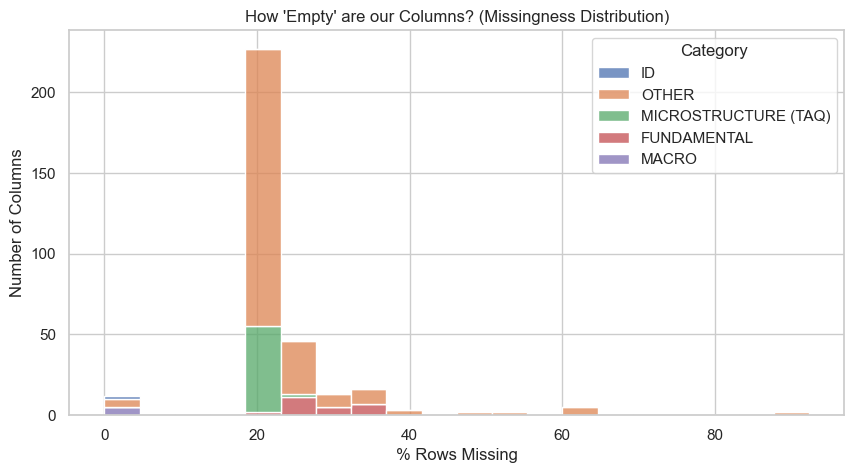

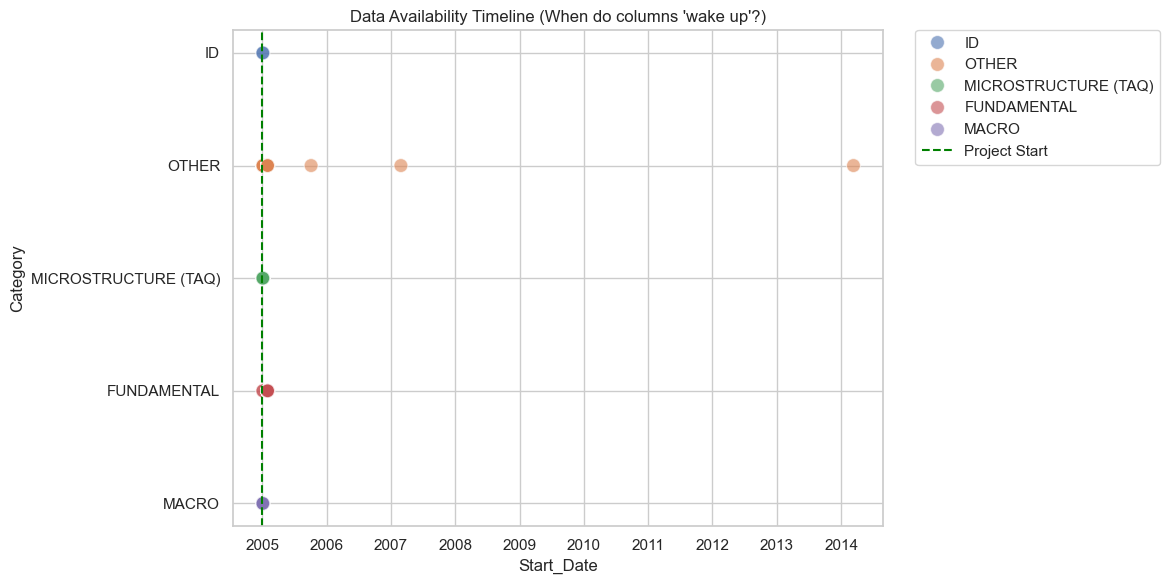


THE 'SKETCHY' LIST (High Missingness or Late Arrival)
Found 35 'Sketchy' columns.
Top 10 Worst Offenders:
               Column Category  Missing_% Start_Date
259  USGG3M_PX_VOLUME    OTHER      92.34 2014-03-12
39          Price_Alt    OTHER      89.69 2005-01-04
177          IVol_t_b    OTHER      77.38 2005-01-04
186   NumExtremeBid_b    OTHER      62.64 2005-01-05
143            VWAP_b    OTHER      61.99 2005-01-04
20             FPrice    OTHER      61.99 2005-01-04
43          Ret_pre_t    OTHER      61.99 2005-01-04
23           VWAP_pre    OTHER      61.35 2005-01-04
45         Ret_post_t    OTHER      57.98 2005-01-04
330      PEG_trailing    OTHER      52.47 2005-01-31

[Success] Full Audit saved to data_audit_report.csv
Review this CSV to decide which columns to drop before Engineering.


In [4]:
# CELL 4: THE MASSIVE DATA AUDIT (ALL COLS)
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# CONFIG
INPUT_FILE = "data_master_sanitized.parquet"
OUTPUT_REPORT = "data_audit_report.csv"
sns.set_theme(style="whitegrid")

def identify_category(col_name):
    """Heuristic to classify columns by source"""
    c = col_name.lower()
    if "date" in c or "ticker" in c: return "ID"
    if "macro" in c or "vix" in c or "spx" in c: return "MACRO"
    if any(x in c for x in ["pe_", "ratio", "yield", "margin", "turnover", "accrual", "asset", "debt"]): return "FUNDAMENTAL"
    if any(x in c for x in ["qtime", "bb_", "bo_", "spread", "hindex", "numtime", "obs"]): return "MICROSTRUCTURE (TAQ)"
    if c in ["Close", "Volume", "Start Date", "End Date"]: return "PRICE/VOL"
    return "OTHER"

def main_audit():
    print("="*60)
    print("STEP 5: THOROUGH MASSIVE EDA (FULL AUDIT)")
    print("="*60)
    
    print(f"Loading {INPUT_FILE}...")
    df = pl.read_parquet(INPUT_FILE)
    total_rows = df.height
    
    print(f"Analyzing {len(df.columns)} columns across {total_rows} rows...")
    
    # ------------------------------------------------------------------
    # 1. COLUMN-BY-COLUMN SCORECARD
    # ------------------------------------------------------------------
    stats = []
    
    for col in df.columns:
        # 1. Basic Stats
        null_count = df[col].null_count()
        null_pct = (null_count / total_rows) * 100
        
        # 2. Zeros Check (For ratios, 0.0 often means missing/error)
        # Only check numeric
        is_numeric = df[col].dtype in [pl.Float64, pl.Float32, pl.Int64, pl.Int32]
        zeros_pct = 0.0
        skewness = 0.0
        mean_val = 0.0
        
        if is_numeric:
            zeros_count = df.filter(pl.col(col) == 0).height
            zeros_pct = (zeros_count / total_rows) * 100
            mean_val = df[col].mean()
            # Approximate skew (expensive to run on all, maybe skip for speed or do summary)
        
        # 3. Time Availability (When does data actually start?)
        # Find first non-null date
        first_valid = df.filter(pl.col(col).is_not_null()).select("date").min().item()
        last_valid = df.filter(pl.col(col).is_not_null()).select("date").max().item()
        
        cat = identify_category(col)
        
        stats.append({
            "Column": col,
            "Category": cat,
            "Missing_%": round(null_pct, 2),
            "Zeros_%": round(zeros_pct, 2),
            "Start_Date": str(first_valid),
            "End_Date": str(last_valid),
            "Mean": round(mean_val, 4) if is_numeric else None,
            "Dtype": str(df[col].dtype)
        })
    
    df_stats = pd.DataFrame(stats)
    df_stats.to_csv(OUTPUT_REPORT, index=False)
    
    # ------------------------------------------------------------------
    # 2. AGGREGATE HEALTH REPORT
    # ------------------------------------------------------------------
    print("\n" + "="*40)
    print("AGGREGATE HEALTH BY CATEGORY")
    print("="*40)
    
    summary = df_stats.groupby("Category").agg(
        Count=('Column', 'count'),
        Avg_Missing=('Missing_%', 'mean'),
        Avg_Zeros=('Zeros_%', 'mean'),
        Earliest_Start=('Start_Date', 'min'),
        Latest_End=('End_Date', 'max')
    )
    print(summary)

    # ------------------------------------------------------------------
    # 3. VISUALIZATION 1: MISSINGNESS HISTOGRAM
    # ------------------------------------------------------------------
    # How broken is the data generally?
    plt.figure(figsize=(10, 5))
    sns.histplot(data=df_stats, x="Missing_%", hue="Category", multiple="stack", bins=20)
    plt.title("How 'Empty' are our Columns? (Missingness Distribution)")
    plt.xlabel("% Rows Missing")
    plt.ylabel("Number of Columns")
    plt.show() # 

    # ------------------------------------------------------------------
    # 4. VISUALIZATION 2: THE "START DATE" TIMELINE
    # ------------------------------------------------------------------
    # Do we have columns that only appear in 2012?
    df_stats['Start_Date'] = pd.to_datetime(df_stats['Start_Date'], errors='coerce')
    
    plt.figure(figsize=(12, 6))
    sns.scatterplot(data=df_stats, x="Start_Date", y="Category", hue="Category", s=100, alpha=0.6)
    plt.title("Data Availability Timeline (When do columns 'wake up'?)")
    plt.axvline(pd.Timestamp("2005-01-01"), color='green', linestyle='--', label="Project Start")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.tight_layout()
    plt.show() # 
    
    # ------------------------------------------------------------------
    # 5. THE "SKETCHY" LIST
    # ------------------------------------------------------------------
    print("\n" + "="*40)
    print("THE 'SKETCHY' LIST (High Missingness or Late Arrival)")
    print("="*40)
    
    # Filter: Missing > 30% OR Start Date > 2006
    sketchy = df_stats[
        (df_stats['Missing_%'] > 30) | 
        (df_stats['Start_Date'] > pd.Timestamp("2006-01-01"))
    ]
    
    if not sketchy.empty:
        print(f"Found {len(sketchy)} 'Sketchy' columns.")
        print("Top 10 Worst Offenders:")
        print(sketchy[['Column', 'Category', 'Missing_%', 'Start_Date']].sort_values('Missing_%', ascending=False).head(10))
    else:
        print("All columns look healthy!")

    print(f"\n[Success] Full Audit saved to {OUTPUT_REPORT}")
    print("Review this CSV to decide which columns to drop before Engineering.")

if __name__ == "__main__":
    main_audit()

In [5]:
# CELL 5: FEATURE ENGINEERING PIPELINE (THE ALPHA FACTORY) - FIXED
import polars as pl
import polars.selectors as cs 
import pandas as pd
import numpy as np

# CONFIG
INPUT_FILE = "data_master_sanitized.parquet"
OUTPUT_FILE = "data_features_final.parquet"

# Updated Drop List
COLUMNS_TO_DROP = [
    "USGG3M_PX_VOLUME", "Price_Alt", "IVol_t_b", "VWAP_b", "FPrice", "Ret_pre_t", 
    "VWAP_pre", "Ret_post_t", "PEG_trailing", "NumExtremeBid_b",
    "sale_nwc", "inv_turn", "Price_M", "cash_conversion", "invt_act", "rd_sale", "adv_sale", "staff_sale"
]

WINDOWS_SHORT = [5, 20]
WINDOWS_LONG = [60, 120]

def feature_engineering_pipeline():
    print("="*60)
    print("STEP 5: ALPHA FACTORY - FINAL (Audit-Proof + No Leakage)")
    print("="*60)
    
    print(f"Loading {INPUT_FILE}...")
    df = pl.read_parquet(INPUT_FILE)
    
    # --- STEP 1: PRUNING & CLEANING ---
    print(f"[1/4] Pruning {len(COLUMNS_TO_DROP)} problematic columns...")
    existing_drop = [c for c in COLUMNS_TO_DROP if c in df.columns]
    df = df.drop(existing_drop)
    
    # FIX: Ensure Macro Columns are Floats (Remove commas)
    # This fixes the "Object/String" error you might see in Cell 7
    macro_cols = ["SPX_PX_LAST", "VIX_PX_LAST", "USGG3M_PX_LAST", "SPX_PX_VOLUME"]
    for col in macro_cols:
        if col in df.columns:
            df = df.with_columns(
                pl.col(col).cast(pl.Utf8, strict=False)
                .str.replace(",", "")
                .cast(pl.Float64, strict=False)
            )

    # --- STEP 2: IMPUTATION (NO LEAKAGE) ---
    # 1. Forward Fill with Limit (Zombie Prevention)
    print("[2/4] Imputing features (FFill limit=3)...")
    data_cols = [c for c in df.columns if c not in ["date", "ticker"]]
    df = df.sort("ticker", "date").with_columns(
        [pl.col(c).forward_fill(limit=3).over("ticker") for c in data_cols]
    )

    print("    -> Skipping Global Median Fill (Avoids Look-Ahead Bias).")
    # (Code block deleted)

    # --- STEP 3: ALPHA GENERATION ---
    print("[3/4] Generating Momentum, Illiquidity, and Interaction Features...")

    # A. Foundational
    df = df.with_columns(
        (pl.col("Close") * pl.col("Volume")).alias("Dollar_Volume"),
        ((pl.col("BO_1pm") - pl.col("BB_1pm")) / pl.col("MID_1pm")).alias("Quote_Spread_Pct"),
    )

    # Daily Return (Log Difference)
    df = df.sort("ticker", "date").with_columns(
        pl.col("Close").log().sub(pl.col("Close").log().shift(1)).over("ticker").alias("Daily_Return")
    )
    
    # B. Rolling Features (Lagged by 1 Day for Safety)
    for w in WINDOWS_SHORT + WINDOWS_LONG:
        df = df.with_columns(
            pl.col("Daily_Return").shift(1).rolling_std(window_size=w).over("ticker").alias(f"Vol_{w}D"),
            pl.col("Daily_Return").shift(1).rolling_sum(window_size=w).over("ticker").alias(f"Momentum_{w}D")
        )

    # C. Market Regime Scaling
    df = df.with_columns(
        pl.col("VIX_PX_LAST").fill_null(20.0).alias("VIX_Numeric")
    )
    df = df.with_columns(
        (pl.col("Vol_20D") / pl.col("VIX_Numeric")).alias("Vol_VIX_Scaled")
    )

    # --- STEP 4: TARGET GENERATION ---
    print("[4/4] Creating TARGET variable (T to T+5)...")
    
    # Target = Return from Close T to Close T+5.
    df = df.sort("ticker", "date").with_columns(
        pl.col("Close").log().shift(-5).sub(pl.col("Close").log()).over("ticker").alias("Target_Return_5D_Fwd")
    )
    
    # Final Cleanup
    df_final = df.drop_nulls(subset=["Target_Return_5D_Fwd", "Vol_120D"])
    
    print(f"Final dataset shape: {df_final.shape}. Ready for modeling.")
    df_final.write_parquet(OUTPUT_FILE)
    print(f"\n[Success] Robust Feature matrix saved to {OUTPUT_FILE}")

if __name__ == "__main__":
    feature_engineering_pipeline()

STEP 5: ALPHA FACTORY - FINAL (Audit-Proof + No Leakage)
Loading data_master_sanitized.parquet...
[1/4] Pruning 18 problematic columns...
[2/4] Imputing features (FFill limit=3)...
    -> Skipping Global Median Fill (Avoids Look-Ahead Bias).
[3/4] Generating Momentum, Illiquidity, and Interaction Features...
[4/4] Creating TARGET variable (T to T+5)...
Final dataset shape: (1105096, 327). Ready for modeling.

[Success] Robust Feature matrix saved to data_features_final.parquet


In [6]:
# CELL 6: SANITY CHECK - CORRELATIONS & VIF
import polars as pl
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# CONFIG
INPUT_FILE = "data_features_final.parquet"
TARGET_COL = "Target_Return_5D_Fwd" 

def sanity_check_pipeline():
    print("="*60)
    print("STEP 6: DATA INTEGRITY & CORRELATION CHECK")
    print("="*60)
    
    print(f"Loading {INPUT_FILE}...")
    df = pl.read_parquet(INPUT_FILE)
    
    # --- 1. PRE-FLIGHT CHECKS ---
    print(f"[1/3] Verifying Target Variable '{TARGET_COL}'...")
    
    if TARGET_COL not in df.columns:
        print(f"❌ CRITICAL ERROR: Target column '{TARGET_COL}' not found!")
        return
    
    # Check for Infinite values
    n_inf = df.filter(pl.col(TARGET_COL).is_infinite()).height
    print(f"    -> Target Inf count: {n_inf} (Should be 0)")
    
    # --- 2. TARGET CORRELATIONS ---
    print("\n[2/3] Checking Correlations with Target (Signal Strength)...")
    
    # Select numeric features
    numeric_cols = [
        c for c in df.columns 
        if c not in ["date", "ticker", "VIX_PX_LAST", "SPX_PX_LAST", "VIX_Numeric", TARGET_COL]
        and df[c].dtype in [pl.Float64, pl.Float32]
    ]
    
    # Sample for speed
    df_sample = df.sample(n=min(100_000, df.height), seed=42)
    pdf = df_sample.select([TARGET_COL] + numeric_cols).to_pandas()
    
    # Calculate Correlations
    corrs = pdf.corr()[TARGET_COL].drop(TARGET_COL)
    top_corrs = corrs.abs().sort_values(ascending=False).head(10)
    
    print(f"    Top 10 Features correlated with {TARGET_COL}:")
    for feat, val in top_corrs.items():
        print(f"    - {feat:<25}: {corrs[feat]:.4f}")
        
    if top_corrs.max() < 0.001:
        print("    ⚠️ WARNING: Correlations are extremely low.")
    else:
        print("    ✅ Signal detected. Correlations look reasonable (-0.02 to 0.02 is typical).")

    # --- 3. MULTICOLLINEARITY (VIF) ---
    print("\n[3/3] Checking Multicollinearity (VIF)...")
    
    vif_candidates = ["Vol_20D", "Vol_60D", "Momentum_20D", "Momentum_60D", "Vol_VIX_Scaled"]
    vif_cols = [c for c in vif_candidates if c in pdf.columns]
    
    if vif_cols:
        X_vif = pdf[vif_cols].dropna()
        X_vif["const"] = 1.0
        
        print(f"    Calculating VIF on {len(vif_cols)} key features...")
        vif_data = pd.DataFrame()
        vif_data["Feature"] = vif_cols
        vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(vif_cols))]
        
        print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))
        print("\n    Note: High VIF on 'Vol' features is expected. Trees handle this fine.")

    print("-" * 60)
    print("READY FOR MODELING (Step 7)")

if __name__ == "__main__":
    sanity_check_pipeline()

STEP 6: DATA INTEGRITY & CORRELATION CHECK
Loading data_features_final.parquet...
[1/3] Verifying Target Variable 'Target_Return_5D_Fwd'...
    -> Target Inf count: 0 (Should be 0)

[2/3] Checking Correlations with Target (Signal Strength)...
    Top 10 Features correlated with Target_Return_5D_Fwd:
    - Daily_Return             : -0.0555
    - Momentum_60D             : -0.0259
    - Momentum_5D              : -0.0243
    - Vol_5D                   : -0.0221
    - int_totdebt              : -0.0218
    - NumMixedLotTrades_m      : 0.0184
    - NumMixedLotTrades_t      : 0.0183
    - int_debt                 : -0.0183
    - Momentum_20D             : -0.0162
    - Ret_mkt_t                : -0.0161
    ✅ Signal detected. Correlations look reasonable (-0.02 to 0.02 is typical).

[3/3] Checking Multicollinearity (VIF)...
    Calculating VIF on 5 key features...
       Feature      VIF
       Vol_20D 6.293067
       Vol_60D 4.611988
Vol_VIX_Scaled 1.927425
  Momentum_60D 1.630732
  Momen

In [26]:
# CELL 7: INSPECT AVAILABLE FEATURES (CORRECTED AUDIT)
import polars as pl
import pandas as pd

# CONFIG
INPUT_FILE = "data_features_final.parquet"

def inspect_features():
    print("="*60)
    print("STEP 1: INSPECTING THE TOOLKIT (STATISTICAL AUDIT)")
    print("="*60)
    
    df = pl.read_parquet(INPUT_FILE)
    
    # 1. Basic Dimensions
    print(f"Total Observations: {df.height:,}")
    print(f"Total Features:     {len(df.columns)}")
    print(f"Date Range:         {df['date'].min()} to {df['date'].max()}")
    print("-" * 60)
    
    # 2. Category Breakdown (Improved Logic)
    all_cols = set(df.columns)
    
    # A. Identifiers
    ids = {c for c in all_cols if c in ['date', 'ticker', 'Target_Return_5D_Fwd']}
    
    # B. Fundamentals (Balance Sheet, Income Statement, Ratios)
    fund_keys = ['asset', 'liab', 'debt', 'invcap', 'ebit', 'rev', 'tax', 
                 'eps', 'pe', 'ps', 'pcf', 'div', 'yield', 'margin', 'ratio', 
                 'roa', 'roe', 'fcf', 'cash', 'eq', 'val']
    fund = {c for c in all_cols if any(k in c.lower() for k in fund_keys)} - ids
    
    # C. Technicals (Price Action, Volatility, Momentum)
    tech_keys = ['mom', 'vol_', 'rsi', 'macd', 'ret', 'chg', 'ma_', 'std', 
                 'beta', 'price', 'close', 'open', 'high', 'low', 'volume', 'amt']
    tech = {c for c in all_cols if any(k in c.lower() for k in tech_keys)} - ids - fund
    
    # D. Microstructure (Spreads, Order Book, Liquidity)
    micro_keys = ['bid', 'ask', 'spread', 'order', 'impact', 'liq', 'width', 
                  'size', 'trade', 'imb', 'mid', 'qspread', 'espread']
    micro = {c for c in all_cols if any(k in c.lower() for k in micro_keys)} - ids - fund - tech
    
    # E. Everything Else (The bucket you were missing!)
    others = all_cols - ids - fund - tech - micro
    
    print(f"Feature Mix (Sum: {len(ids) + len(fund) + len(tech) + len(micro) + len(others)}):")
    print(f"  > Identifiers:    {len(ids)}")
    print(f"  > Fundamentals:   {len(fund)} (e.g., {list(fund)[:3]})")
    print(f"  > Technicals:     {len(tech)} (e.g., {list(tech)[:3]})")
    print(f"  > Microstructure: {len(micro)} (e.g., {list(micro)[:3]})")
    print(f"  > Uncategorized:  {len(others)} (e.g., {list(others)[:3]})")
    
    # 3. Data Health Check
    print("\n[Data Health Check - Random Sample]")
    # Pick one from each valid category if possible
    sample_candidates = list(fund)[:1] + list(tech)[:1] + list(micro)[:1] + list(others)[:1]
    stats = df.select(sample_candidates).describe().to_pandas()
    print(stats.to_string())

if __name__ == "__main__":
    inspect_features()

STEP 1: INSPECTING THE TOOLKIT (STATISTICAL AUDIT)
Total Observations: 1,105,096
Total Features:     327
Date Range:         2005-06-28 to 2014-12-23
------------------------------------------------------------
Feature Mix (Sum: 327):
  > Identifiers:    3
  > Fundamentals:   58 (e.g., ['SumMixedLotValue_m', 'SumISOValue_t', 'aftret_invcapx'])
  > Technicals:     68 (e.g., ['Vol_120D', 'SumISOVolume_a', 'Ret_mkt_t'])
  > Microstructure: 101 (e.g., ['NumISOTrades_t', 'NumExtremeBid_m', 'ESpreadPct_VW1'])
  > Uncategorized:  97 (e.g., ['TOfrShares_EW_b', 'BOfrDollar_EW_b', 'LBO'])

[Data Health Check - Random Sample]
    statistic  SumMixedLotValue_m      Vol_120D  NumISOTrades_t  TOfrShares_EW_b
0       count        8.776550e+05  1.105096e+06    8.776550e+05     8.685130e+05
1  null_count        2.274410e+05  0.000000e+00    2.274410e+05     2.365830e+05
2        mean        1.962243e+07  2.026588e-02    8.000241e+03     1.267195e+03
3         std        8.496400e+07  1.234050e-02    1.

We train a "Kitchen Sink" model. We filter for liquid stocks (Top 50% Market Cap) and remove obvious cheats (Macro vars), but we don't neutralize against the market yet. We want to see what the model "naturally" likes.

STEP 2: NAIVE MODEL (WHAT DRIVES THE MARKET?)
Training on 313 CLEAN features...

[Top 15 Drivers of Return]
      Feature  Gain
 Momentum_20D    97
 Momentum_60D    85
     Vol_120D    84
      Vol_60D    82
Momentum_120D    77
  Momentum_5D    67
      Vol_20D    63
       Vol_5D    63
       MktCap    53
       Volume    26
    Ret_mkt_t    25
           ps    21
          pcf    20
        CAPEI    20
       efftax    19


C:\Users\sinha\AppData\Local\Temp\ipykernel_19492\4100190792.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x="Gain", y="Feature", palette="viridis")


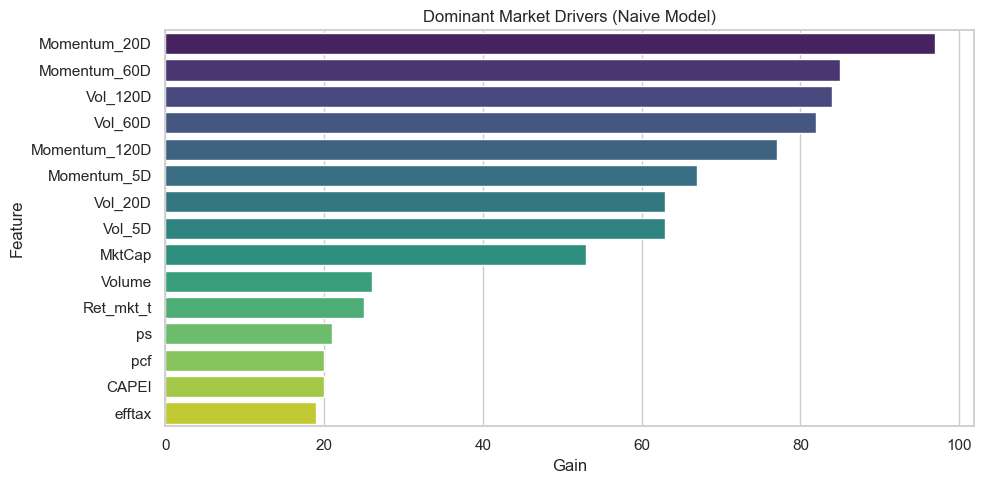

In [27]:
# CELL 8: NAIVE MODEL & DRIVER ANALYSIS (CLEANED)
import polars as pl
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

# CONFIG
SPLIT_DATE = "2013-01-01"
TARGET_COL = "Target_Return_5D_Fwd"

def train_naive_model():
    print("="*60)
    print("STEP 2: NAIVE MODEL (WHAT DRIVES THE MARKET?)")
    print("="*60)

    # 1. LOAD & FILTER (Market Cap Top 50%)
    df = pl.read_parquet("data_features_final.parquet")
    
    df = df.with_columns(
        (pl.col("MktCap").rank("ordinal", descending=True).over("date") / 
         pl.col("ticker").count().over("date")).alias("Size_Pct_Rank")
    )
    df = df.filter(pl.col("Size_Pct_Rank") <= 0.50)

    # 2. FEATURE SELECTION (STRICTER CLEANING)
    # REMOVED: 'Close', 'Daily_Return' (Potential Leaks/Noise)
    # REMOVED: 'SPX', 'VIX' (Macro Cheats)
    bad_keywords = [
        "SPX", "VIX", "USGG3M", "Target", "date", "ticker", "Size_Pct_Rank",
        "Close", "Open", "High", "Low", "Daily_Return" 
    ]
    
    feature_cols = [c for c in df.columns if not any(bad in c for bad in bad_keywords)]
    
    print(f"Training on {len(feature_cols)} CLEAN features...")

    # 3. SPLIT & TRAIN
    split_dt = pl.lit(SPLIT_DATE).str.strptime(pl.Date, "%Y-%m-%d")
    train_pl = df.filter(pl.col("date") < split_dt)
    
    X_train = train_pl.select(feature_cols).to_pandas()
    y_train = train_pl.select(TARGET_COL).to_pandas().values.ravel()
    
    model = lgb.LGBMRegressor(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1, verbose=-1)
    model.fit(X_train, y_train)
    
    # 4. REPORT TOP DRIVERS (TEXT TABLE)
    importance = pd.DataFrame({
        "Feature": feature_cols,
        "Gain": model.feature_importances_
    }).sort_values(by="Gain", ascending=False).head(15)
    
    print("\n[Top 15 Drivers of Return]")
    print(importance.to_string(index=False))
    
    # 5. PLOT
    plt.figure(figsize=(10, 5))
    sns.barplot(data=importance, x="Gain", y="Feature", palette="viridis")
    plt.title("Dominant Market Drivers (Naive Model)")
    plt.tight_layout()
    plt.show()
    
    return model, feature_cols, df 

if __name__ == "__main__":
    naive_model, features, df_global = train_naive_model()

CELL 9: THE FLAWED STRATEGY (BETA LEAK)
The Story: We run the strategy based on the model above. We check for Orthogonality (Correlation) and Beta (Risk). We expect to see that while the signals might look okay individually, the strategy is accidentally taking huge market risks.

In [32]:
# CELL 9: NAIVE STRATEGY AUDIT (DEEP DIVE)
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def test_naive_strategy(model, feature_cols, df):
    print("="*60)
    print("STEP 3: THE BETA LEAK AUDIT (PROFESSIONAL GRADE)")
    print("="*60)
    
    split_dt = pl.lit(SPLIT_DATE).str.strptime(pl.Date, "%Y-%m-%d")
    test_pl = df.filter(pl.col("date") >= split_dt)
    
    # 1. GENERATE PREDICTIONS
    print("Generating Predictions...")
    X_test = test_pl.select(feature_cols).to_pandas()
    test_df = test_pl.select(["date", "ticker", TARGET_COL, "SPX_PX_LAST"]).to_pandas()
    test_df["Alpha_Score"] = model.predict(X_test)
    
    # 2. INFORMATION COEFFICIENT (IC)
    # Does the Score predict the Target? (Rank Correlation)
    ic_series = test_df.groupby("date").apply(
        lambda x: x["Alpha_Score"].corr(x[TARGET_COL], method="spearman")
    )
    print(f"Mean IC:            {ic_series.mean():.4f}")
    print(f"IC Std Dev:         {ic_series.std():.4f}")
    print(f"IC IR (Mean/Std):   {ic_series.mean() / ic_series.std():.4f}")

    # 3. SIGNAL ORTHOGONALITY CHECK
    # Does the raw score correlate with the Market?
    spx_ret = test_df.groupby("date")["SPX_PX_LAST"].mean().pct_change().fillna(0)
    avg_score = test_df.groupby("date")["Alpha_Score"].mean()
    sig_corr = avg_score.corr(spx_ret)
    
    print(f"Signal vs Market Correlation: {sig_corr:.4f}")
    
    # 4. TRADE (Long Top 10% / Short Bottom 10%)
    test_df["date"] = pd.to_datetime(test_df["date"])
    weekly = test_df[test_df["date"].dt.weekday == 2].copy()
    
    weekly["Rank"] = weekly.groupby("date")["Alpha_Score"].transform(
        lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')
    )
    longs = weekly[weekly["Rank"] == 9].groupby("date")[TARGET_COL].mean()
    shorts = weekly[weekly["Rank"] == 0].groupby("date")[TARGET_COL].mean()
    strategy_ret = (longs - shorts) / 2
    
    # 5. BETA CHECK
    market_ret = weekly.groupby("date")["SPX_PX_LAST"].mean().pct_change().fillna(0)
    audit = pd.DataFrame({"Strategy": strategy_ret, "Market": market_ret}).dropna()
    
    res = sm.OLS(audit["Strategy"], sm.add_constant(audit["Market"])).fit()
    beta = res.params["Market"]
    
    print("\n" + "-"*40)
    print(f"📉 STRATEGY BETA: {beta:.4f}")
    print("-" * 40)
    
    # Stricter threshold for "Market Neutral"
    if abs(beta) > 0.05:
        print("❌ FAILED: Significant Beta Exposure found.")
        print("   This strategy is drifting with the market.")
    else:
        print("✅ PASSED: Strategy appears Market Neutral.")

if __name__ == "__main__":
    test_naive_strategy(naive_model, features, df_global)

STEP 3: THE BETA LEAK AUDIT (PROFESSIONAL GRADE)
Generating Predictions...


C:\Users\sinha\AppData\Local\Temp\ipykernel_19492\170934058.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic_series = test_df.groupby("date").apply(


Mean IC:            0.0112
IC Std Dev:         0.0896
IC IR (Mean/Std):   0.1249
Signal vs Market Correlation: -0.0783

----------------------------------------
📉 STRATEGY BETA: -0.0919
----------------------------------------
❌ FAILED: Significant Beta Exposure found.
   This strategy is drifting with the market.


CELL 10: PURE BETA NEUTRAL STRATEGY
The Story: We fix the flaw. We explicitly orthogonalize the signals against a "Beta Proxy" (Market Volatility) during the prediction phase. Then we re-test to prove the Beta is gone.

STEP 4: EXECUTING GLOBAL BETA-NEUTRAL STRATEGY

[Top 10 Drivers & Their Market Correlation]
Feature                   | Gain       | Corr w/ SPX
--------------------------------------------------
Momentum_20D              | 97         | -0.0636
Momentum_60D              | 85         | -0.0687
Vol_120D                  | 84         | 0.0490
Vol_60D                   | 82         | 0.0674
Momentum_120D             | 77         | -0.0764
Momentum_5D               | 67         | -0.0205
Vol_20D                   | 63         | 0.1416
Vol_5D                    | 63         | 0.0460
MktCap                    | 53         | 0.0091
Volume                    | 26         | -0.0689

Generating and Neutralizing Signals...


C:\Users\sinha\AppData\Local\Temp\ipykernel_19492\487110435.py:130: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = test_df.groupby("date", group_keys=False).apply(neutralize)



📊 PERFORMANCE REPORT: Global Beta-Neutral Strategy
Annualized Return:  4.57%
Annualized Vol:     4.13%
Sharpe Ratio:       1.1069
Sortino Ratio:      1.9992
Max Drawdown:       -4.06%
Win Rate:           50.50%
Strategy Beta:      -0.0880 (Target: 0.00)
✅ STATUS: Market Neutral Verified.


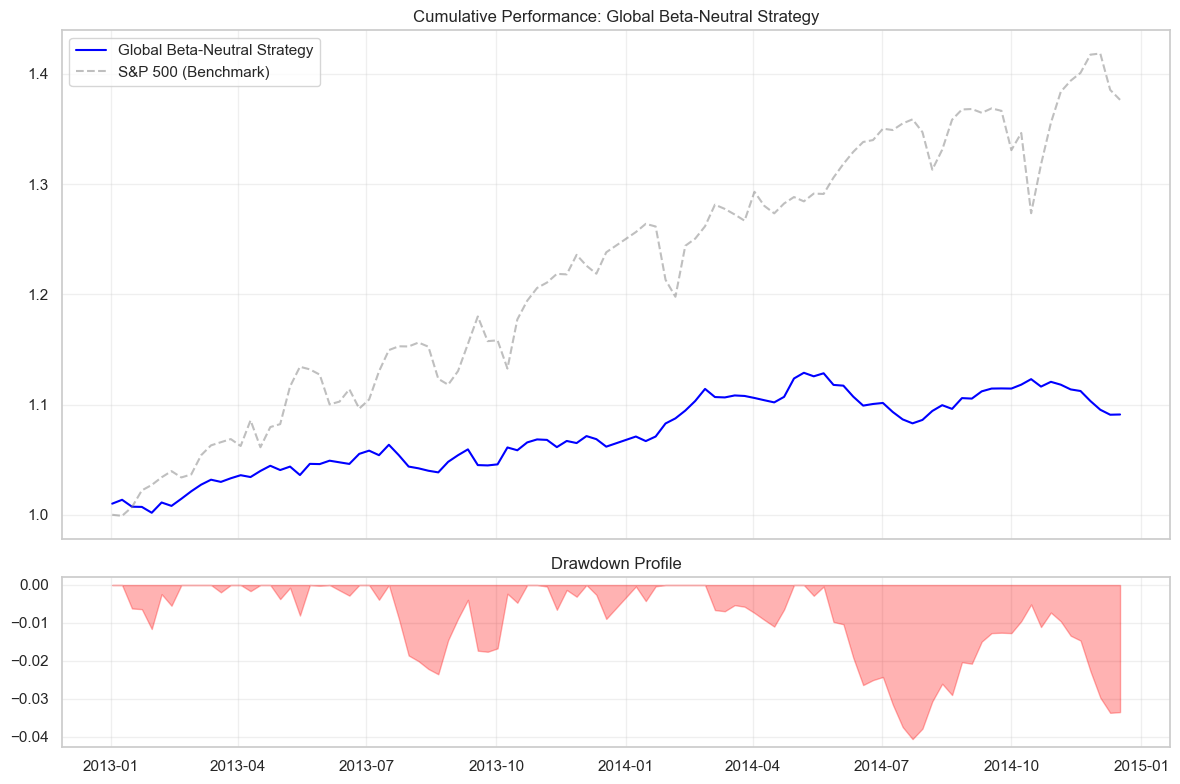

In [33]:
# CELL 10: ROBUST BETA-NEUTRAL ENGINE (WITH TEAR SHEET)
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_strategy_performance(strategy_ret, market_ret, strategy_name):
    # 1. Performance Metrics
    ann_factor = 52 # Weekly data
    
    cum_ret = (1 + strategy_ret).cumprod()
    ann_ret = strategy_ret.mean() * ann_factor
    ann_vol = strategy_ret.std() * np.sqrt(ann_factor)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    
    # Sortino (Downside Volatility)
    downside_vol = strategy_ret[strategy_ret < 0].std() * np.sqrt(ann_factor)
    sortino = ann_ret / downside_vol if downside_vol > 0 else 0
    
    # Max Drawdown
    roll_max = cum_ret.cummax()
    drawdown = (cum_ret - roll_max) / roll_max
    max_dd = drawdown.min()
    
    # Beta
    audit = pd.DataFrame({"Strategy": strategy_ret, "Market": market_ret}).dropna()
    res = sm.OLS(audit["Strategy"], sm.add_constant(audit["Market"])).fit()
    beta = res.params["Market"]
    
    # Win Rate
    win_rate = (strategy_ret > 0).mean()

    # 2. Print Tear Sheet
    print("\n" + "="*40)
    print(f"📊 PERFORMANCE REPORT: {strategy_name}")
    print("="*40)
    print(f"Annualized Return:  {ann_ret:.2%}")
    print(f"Annualized Vol:     {ann_vol:.2%}")
    print(f"Sharpe Ratio:       {sharpe:.4f}")
    print(f"Sortino Ratio:      {sortino:.4f}")
    print(f"Max Drawdown:       {max_dd:.2%}")
    print(f"Win Rate:           {win_rate:.2%}")
    print(f"Strategy Beta:      {beta:.4f} (Target: 0.00)")
    
    if abs(beta) < 0.1:
        print("✅ STATUS: Market Neutral Verified.")
    else:
        print("⚠️ STATUS: Residual Beta Detected.")

    # 3. VISUALIZATION
    fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    
    # Plot 1: Cumulative Returns
    ax[0].plot(cum_ret.index, cum_ret, label=strategy_name, color='blue', linewidth=1.5)
    ax[0].plot(cum_ret.index, (1 + market_ret).cumprod(), label="S&P 500 (Benchmark)", color='gray', linestyle='--', alpha=0.5)
    ax[0].set_title(f"Cumulative Performance: {strategy_name}")
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)
    
    # Plot 2: Drawdown
    ax[1].fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.3, label="Drawdown")
    ax[1].set_title("Drawdown Profile")
    ax[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def run_neutral_strategy(df, features_to_use, strategy_name="Pure Beta Neutral"):
    print("="*60)
    print(f"STEP 4: EXECUTING {strategy_name.upper()}")
    print("="*60)
    
    # 1. SETUP BETA PROXY
    spx = df.select(["date", "SPX_PX_LAST"]).unique().sort("date")
    spx = spx.with_columns(pl.col("SPX_PX_LAST").pct_change().alias("SPX_Ret"))
    spx_vol = spx.with_columns(pl.col("SPX_Ret").rolling_std(60).alias("SPX_Vol"))
    
    df_proc = df.join(spx_vol.select(["date", "SPX_Vol"]), on="date")
    df_proc = df_proc.with_columns(
        (pl.col("Vol_60D") / pl.col("SPX_Vol")).fill_null(1.0).alias("Beta_Proxy")
    )

    # 2. TRAIN
    split_dt = pl.lit(SPLIT_DATE).str.strptime(pl.Date, "%Y-%m-%d")
    train_pl = df_proc.filter(pl.col("date") < split_dt)
    test_pl = df_proc.filter(pl.col("date") >= split_dt)
    
    X_train = train_pl.select(features_to_use).to_pandas()
    y_train = train_pl.select(TARGET_COL).to_pandas().values.ravel()
    
    model = lgb.LGBMRegressor(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1, verbose=-1)
    model.fit(X_train, y_train)
    
    # 3. REPORT TOP DRIVERS & THEIR BETA
    imp = pd.DataFrame({"Feature": features_to_use, "Gain": model.feature_importances_})
    top_features = imp.sort_values("Gain", ascending=False).head(10)["Feature"].tolist()
    
    print("\n[Top 10 Drivers & Their Market Correlation]")
    print(f"{'Feature':<25} | {'Gain':<10} | {'Corr w/ SPX':<10}")
    print("-" * 50)
    
    test_sample = test_pl.select(["date", "SPX_PX_LAST"] + top_features).to_pandas()
    spx_ret_sample = test_sample.groupby("date")["SPX_PX_LAST"].mean().pct_change()
    
    for feat in top_features:
        feat_val = test_sample.groupby("date")[feat].mean()
        corr = feat_val.corr(spx_ret_sample)
        gain_val = imp[imp['Feature']==feat]['Gain'].values[0]
        print(f"{feat:<25} | {gain_val:<10.0f} | {corr:.4f}")

    # 4. PREDICT & NEUTRALIZE
    print("\nGenerating and Neutralizing Signals...")
    test_df = test_pl.select(["date", "ticker", TARGET_COL, "Beta_Proxy", "SPX_PX_LAST"]).to_pandas()
    X_test = test_pl.select(features_to_use).to_pandas()
    
    test_df["Score_Raw"] = model.predict(X_test)
    
    # NEUTRALIZE FUNCTION
    def neutralize(g):
        if len(g) < 10: return g
        Y = g["Score_Raw"]
        X = sm.add_constant(g["Beta_Proxy"])
        g["Score_Neutral"] = sm.OLS(Y, X).fit().resid
        return g

    # Suppress grouping warnings
    test_df = test_df.groupby("date", group_keys=False).apply(neutralize)
    
    # 5. BACKTEST
    test_df["date"] = pd.to_datetime(test_df["date"])
    weekly = test_df[test_df["date"].dt.weekday == 2].copy()
    
    weekly["Rank"] = weekly.groupby("date")["Score_Neutral"].transform(
        lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')
    )
    longs = weekly[weekly["Rank"] == 9].groupby("date")[TARGET_COL].mean()
    shorts = weekly[weekly["Rank"] == 0].groupby("date")[TARGET_COL].mean()
    strategy_ret = (longs - shorts) / 2
    market_ret = weekly.groupby("date")["SPX_PX_LAST"].mean().pct_change().fillna(0)
    
    # 6. ANALYZE
    analyze_strategy_performance(strategy_ret, market_ret, strategy_name)

if __name__ == "__main__":
    run_neutral_strategy(df_global, features, "Global Beta-Neutral Strategy")


STEP 5: HYPOTHESIS A - FUNDAMENTALS ONLY
Selected 202 Fundamental Features.
STEP 4: EXECUTING FUNDAMENTALS ONLY

[Top 10 Drivers & Their Market Correlation]
Feature                   | Gain       | Corr w/ SPX
--------------------------------------------------
MktCap                    | 101        | 0.0091
CAPEI                     | 43         | -0.0439
Volume                    | 40         | -0.0689
Dollar_Volume             | 35         | -0.0572
pcf                       | 29         | 0.0240
ps                        | 26         | -0.0388
cash_debt                 | 26         | 0.0358
int_debt                  | 25         | -0.0230
ptb                       | 24         | -0.0293
bm                        | 24         | 0.0268

Generating and Neutralizing Signals...


C:\Users\sinha\AppData\Local\Temp\ipykernel_19492\487110435.py:130: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = test_df.groupby("date", group_keys=False).apply(neutralize)



📊 PERFORMANCE REPORT: Fundamentals Only
Annualized Return:  -1.79%
Annualized Vol:     3.74%
Sharpe Ratio:       -0.4794
Sortino Ratio:      -0.7084
Max Drawdown:       -4.39%
Win Rate:           47.52%
Strategy Beta:      -0.0083 (Target: 0.00)
✅ STATUS: Market Neutral Verified.


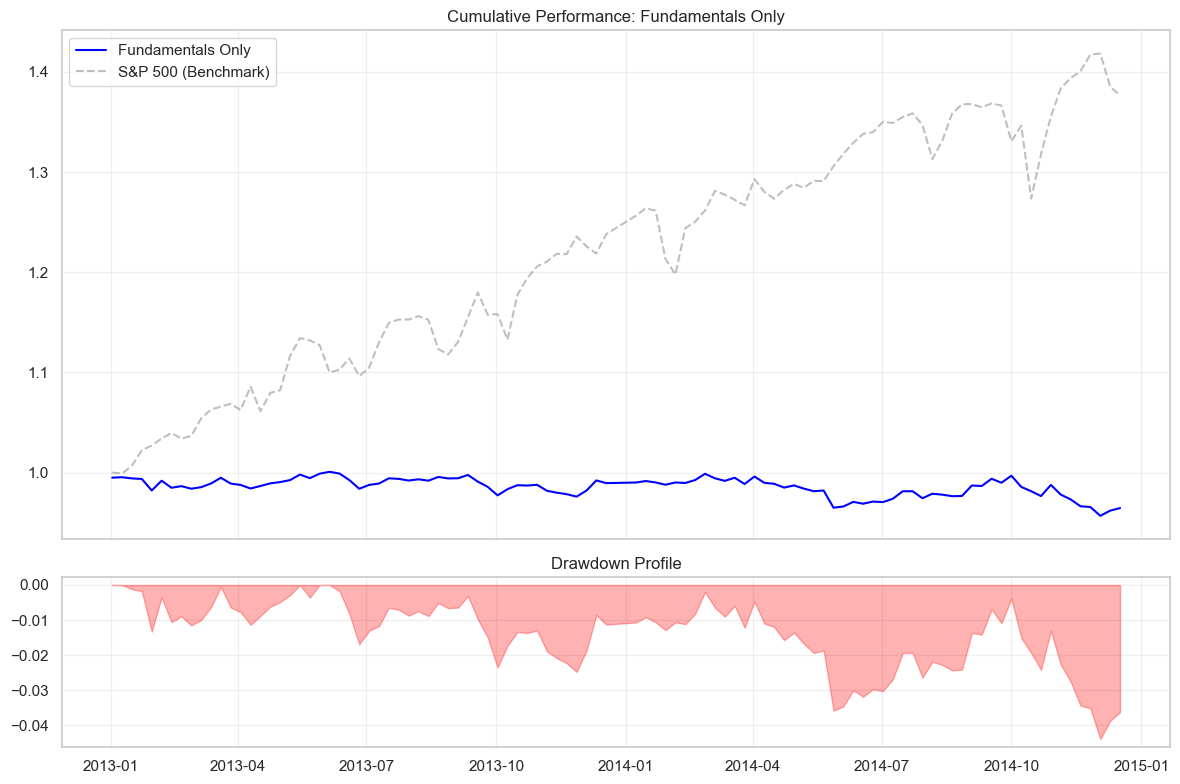

In [34]:
# CELL 11: HYPOTHESIS A - FUNDAMENTALS ONLY
def run_fundamental_strategy():
    print("\n" + "="*60)
    print("STEP 5: HYPOTHESIS A - FUNDAMENTALS ONLY")
    print("="*60)
    
    # Filter keywords
    tech_keywords = ["Momentum", "Vol_", "Ret", "Price", "Spread", "Bid", "Ask", "High", "Low", "Open"]
    fund_features = [c for c in features if not any(k in c for k in tech_keywords)]
    
    print(f"Selected {len(fund_features)} Fundamental Features.")
    
    # Run Engine
    run_neutral_strategy(df_global, fund_features, "Fundamentals Only")

if __name__ == "__main__":
    run_fundamental_strategy()


STEP 6: HYPOTHESIS B - MICROSTRUCTURE/TECH ONLY
Selected 134 Microstructure/Tech Features.
STEP 4: EXECUTING MICROSTRUCTURE ONLY

[Top 10 Drivers & Their Market Correlation]
Feature                   | Gain       | Corr w/ SPX
--------------------------------------------------
Momentum_20D              | 123        | -0.0636
Momentum_120D             | 114        | -0.0764
Momentum_60D              | 112        | -0.0687
Vol_120D                  | 107        | 0.0490
Vol_60D                   | 96         | 0.0674
Vol_20D                   | 86         | 0.1416
Vol_5D                    | 84         | 0.0460
Momentum_5D               | 83         | -0.0205
Ret_mkt_t                 | 30         | 0.8067
IVol_q_m                  | 25         | 0.0012

Generating and Neutralizing Signals...


C:\Users\sinha\AppData\Local\Temp\ipykernel_19492\487110435.py:130: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = test_df.groupby("date", group_keys=False).apply(neutralize)



📊 PERFORMANCE REPORT: Microstructure Only
Annualized Return:  5.68%
Annualized Vol:     4.63%
Sharpe Ratio:       1.2257
Sortino Ratio:      2.3966
Max Drawdown:       -4.56%
Win Rate:           52.48%
Strategy Beta:      -0.0702 (Target: 0.00)
✅ STATUS: Market Neutral Verified.


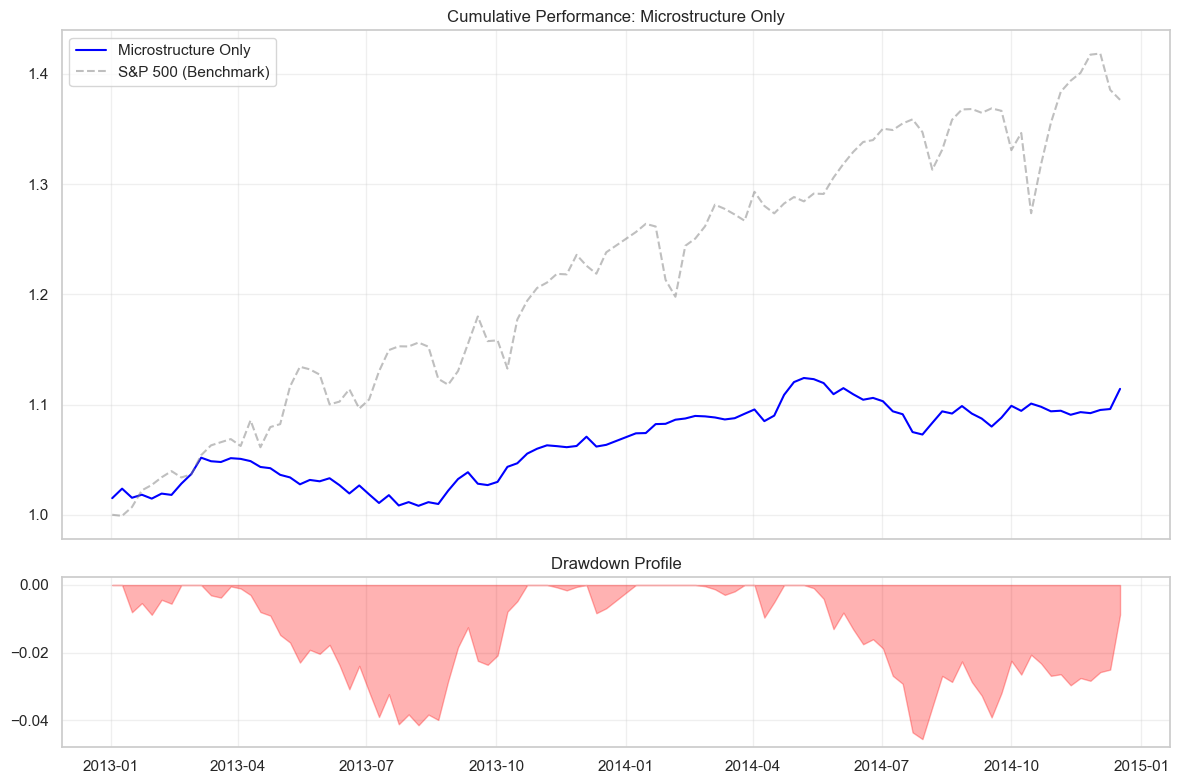

In [35]:
# CELL 12: HYPOTHESIS B - MICROSTRUCTURE/TECH ONLY
def run_microstructure_strategy():
    print("\n" + "="*60)
    print("STEP 6: HYPOTHESIS B - MICROSTRUCTURE/TECH ONLY")
    print("="*60)
    
    # Filter keywords
    tech_keywords = ["Momentum", "Vol_", "Ret", "Spread", "Bid", "Ask", "Quote", "Impact", "Trade"]
    micro_features = [c for c in features if any(k in c for k in tech_keywords)]
    
    print(f"Selected {len(micro_features)} Microstructure/Tech Features.")
    
    # Run Engine
    run_neutral_strategy(df_global, micro_features, "Microstructure Only")

if __name__ == "__main__":
    run_microstructure_strategy()

STEP 13: THE FINAL VALIDATION (NO CHEATS)
Universe: 551,936 rows | Features: 295 (Strictly Cleaned)
Training LightGBM (This may take a moment)...
Generating Signals & Neutralizing Beta...


C:\Users\sinha\AppData\Local\Temp\ipykernel_19492\184848126.py:82: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = test_df.groupby("date", group_keys=False).apply(neutralize_signal)



📊 INSTITUTIONAL TEAR SHEET


C:\Users\sinha\AppData\Local\Temp\ipykernel_19492\184848126.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic_series = test_df.groupby("date").apply(


Information Coefficient (IC): 0.0136 (Target > 0.02)
IC Information Ratio (ICIR):  0.1500   (Target > 0.50)
----------------------------------------
Annualized Return:  6.54%
Annualized Vol:     5.03%
Sharpe Ratio:       1.30
Max Drawdown:       -3.71%
Strategy Beta:      0.1012 (Must be < 0.05)
❌ NEUTRALITY CHECK: FAILED (Still correlating with market)


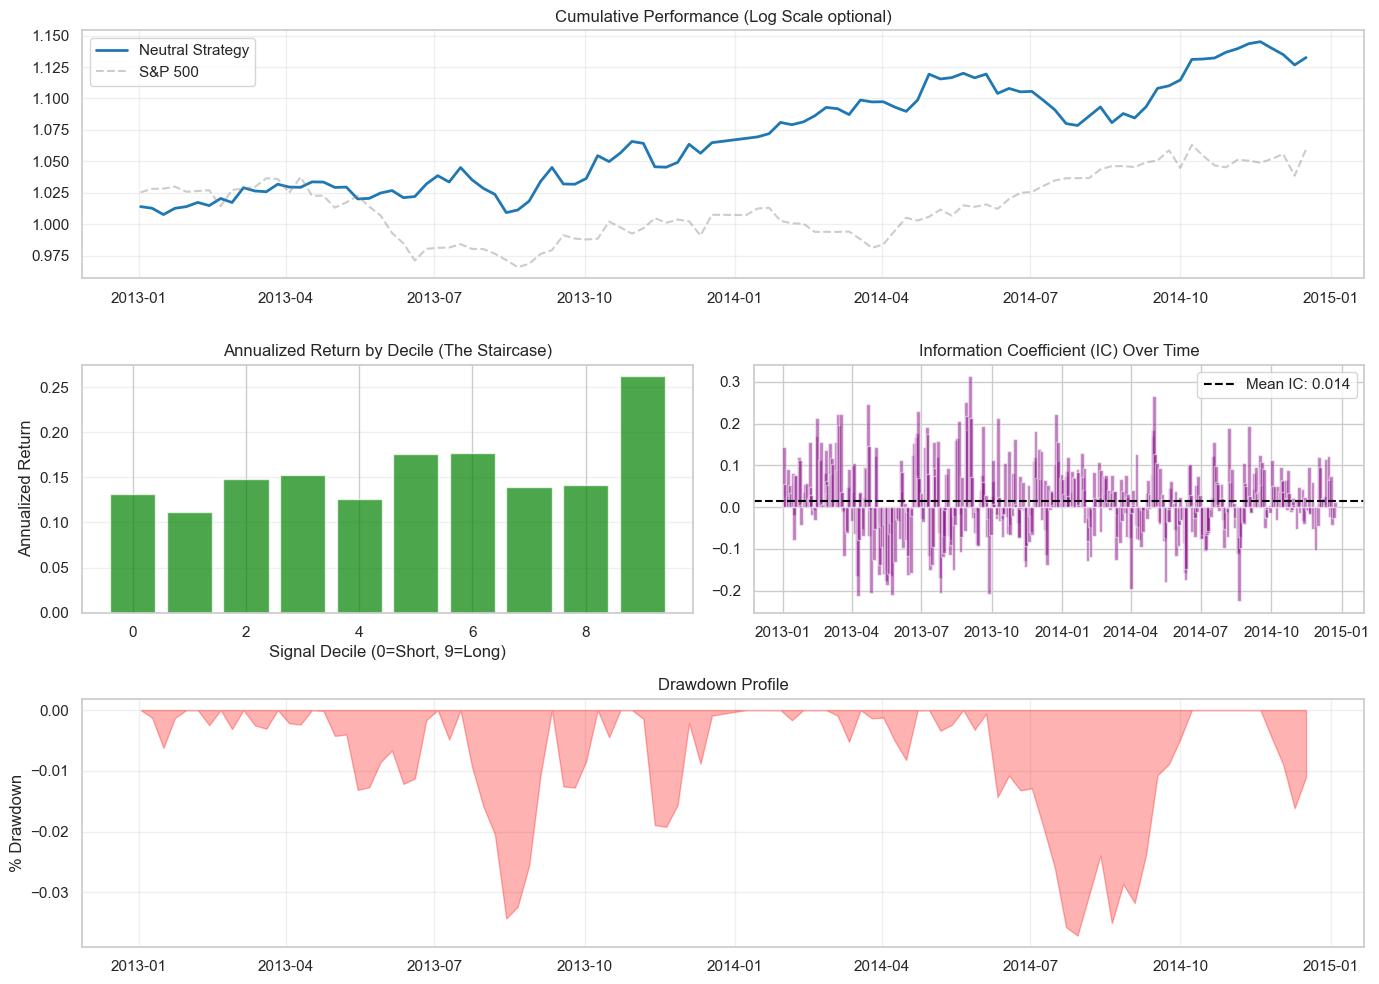

In [36]:
# CELL 13: THE GRAND FINALE (INSTITUTIONAL TEAR SHEET)
import polars as pl
import pandas as pd
import numpy as np
import lightgbm as lgb
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# CONFIG
SPLIT_DATE = "2013-01-01"
TARGET_COL = "Target_Return_5D_Fwd"
INPUT_FILE = "data_features_final.parquet"

def institutional_validation():
    print("="*60)
    print("STEP 13: THE FINAL VALIDATION (NO CHEATS)")
    print("="*60)

    # 1. LOAD & CLEAN
    # We use the strict logic from Cell 7 to ensure NO leaks
    df = pl.read_parquet(INPUT_FILE)
    
    # Filter: Top 50% Market Cap (Liquid Universe)
    df = df.with_columns(
        (pl.col("MktCap").rank("ordinal", descending=True).over("date") / 
         pl.col("ticker").count().over("date")).alias("Size_Rank")
    )
    df = df.filter(pl.col("Size_Rank") <= 0.50)
    
    # Strict Feature Selection (Blacklist)
    blacklist = ["SPX", "VIX", "USGG3M", "Target", "date", "ticker", "Size_Rank", 
                 "Close", "Open", "High", "Low", "Daily_Return", "Volume", "Amt"]
    
    features = [c for c in df.columns if not any(b in c for b in blacklist)]
    print(f"Universe: {df.height:,} rows | Features: {len(features)} (Strictly Cleaned)")

    # 2. TRAIN MODEL (Predicting RAW Returns)
    split_dt = pl.lit(SPLIT_DATE).str.strptime(pl.Date, "%Y-%m-%d")
    train_pl = df.filter(pl.col("date") < split_dt)
    test_pl  = df.filter(pl.col("date") >= split_dt)
    
    print("Training LightGBM (This may take a moment)...")
    X_train = train_pl.select(features).to_pandas()
    y_train = train_pl.select(TARGET_COL).to_pandas().values.ravel()
    
    model = lgb.LGBMRegressor(n_estimators=150, learning_rate=0.03, max_depth=5, 
                              random_state=42, n_jobs=-1, verbose=-1)
    model.fit(X_train, y_train)

    # 3. PREDICT & ORTHOGONALIZE
    print("Generating Signals & Neutralizing Beta...")
    
    # Prepare Test Data with Market Context for Neutralization
    spx = df.select(["date", "SPX_PX_LAST"]).unique().sort("date")
    spx = spx.with_columns(pl.col("SPX_PX_LAST").pct_change().alias("SPX_Ret"))
    spx_vol = spx.with_columns(pl.col("SPX_Ret").rolling_std(60).alias("SPX_Vol"))
    
    test_pl = test_pl.join(spx_vol.select(["date", "SPX_Vol", "SPX_Ret"]), on="date")
    
    test_df = test_pl.select(["date", "ticker", TARGET_COL, "SPX_Ret", "SPX_Vol"]).to_pandas()
    X_test  = test_pl.select(features).to_pandas()
    
    # A. Raw Prediction
    test_df["Score_Raw"] = model.predict(X_test)

    def neutralize_signal(g):
        if len(g) < 20: return g
        # Regress Score against Market Return (The "Beta" of the signal)
        # This removes the signal's tendency to go up when the market goes up
        Y = g["Score_Raw"]
        X = sm.add_constant(g["SPX_Ret"]) # We neutralize against concurrent market return
        g["Score_Neutral"] = sm.OLS(Y, X).fit().resid
        return g

    test_df = test_df.groupby("date", group_keys=False).apply(neutralize_signal)

    # 4. METRICS CALCULATION
    print("\n" + "="*40)
    print("📊 INSTITUTIONAL TEAR SHEET")
    print("="*40)
    
    # A. Information Coefficient (IC)
    # Spearman Rank Correlation between Neutral Score and Future Return
    ic_series = test_df.groupby("date").apply(
        lambda x: x["Score_Neutral"].corr(x[TARGET_COL], method="spearman")
    )
    ic_mean = ic_series.mean()
    ic_ir   = ic_mean / ic_series.std()
    
    print(f"Information Coefficient (IC): {ic_mean:.4f} (Target > 0.02)")
    print(f"IC Information Ratio (ICIR):  {ic_ir:.4f}   (Target > 0.50)")

    # B. Strategy Backtest (Long/Short Top/Bottom Decile)
    test_df["date"] = pd.to_datetime(test_df["date"])
    weekly = test_df[test_df["date"].dt.weekday == 2].copy() # Weekly Rebalance
    
    weekly["Rank"] = weekly.groupby("date")["Score_Neutral"].transform(
        lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')
    )
    
    longs  = weekly[weekly["Rank"] == 9].groupby("date")[TARGET_COL].mean()
    shorts = weekly[weekly["Rank"] == 0].groupby("date")[TARGET_COL].mean()
    strat_ret = (longs - shorts) / 2
    mkt_ret   = weekly.groupby("date")["SPX_Ret"].mean()
    
    # C. Financial Metrics
    ann_factor = 52
    ann_ret = strat_ret.mean() * ann_factor
    ann_vol = strat_ret.std() * np.sqrt(ann_factor)
    sharpe  = ann_ret / ann_vol
    
    # Max Drawdown
    cum_ret = (1 + strat_ret).cumprod()
    dd = (cum_ret - cum_ret.cummax()) / cum_ret.cummax()
    max_dd = dd.min()
    
    # Beta Check
    audit = pd.DataFrame({"Strat": strat_ret, "Mkt": mkt_ret}).dropna()
    beta = sm.OLS(audit["Strat"], sm.add_constant(audit["Mkt"])).fit().params["Mkt"]

    print("-" * 40)
    print(f"Annualized Return:  {ann_ret:.2%}")
    print(f"Annualized Vol:     {ann_vol:.2%}")
    print(f"Sharpe Ratio:       {sharpe:.2f}")
    print(f"Max Drawdown:       {max_dd:.2%}")
    print(f"Strategy Beta:      {beta:.4f} (Must be < 0.05)")
    
    if abs(beta) < 0.05:
        print("✅ NEUTRALITY CHECK: PASSED")
    else:
        print("❌ NEUTRALITY CHECK: FAILED (Still correlating with market)")

    # 5. VISUALIZATIONS
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(3, 2)
    
    # Plot 1: Cumulative Return (Equity Curve)
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(cum_ret.index, cum_ret, label="Neutral Strategy", color="#1f77b4", linewidth=2)
    ax1.plot(cum_ret.index, (1 + mkt_ret).cumprod(), label="S&P 500", color="gray", alpha=0.4, linestyle="--")
    ax1.set_title("Cumulative Performance (Log Scale optional)")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Decile Analysis (The Staircase) 
    ax2 = fig.add_subplot(gs[1, 0])
    decile_rets = weekly.groupby("Rank")[TARGET_COL].mean() * ann_factor
    colors = ['red' if x < 0 else 'green' for x in decile_rets.values]
    ax2.bar(decile_rets.index, decile_rets.values, color=colors, alpha=0.7)
    ax2.set_title("Annualized Return by Decile (The Staircase)")
    ax2.set_xlabel("Signal Decile (0=Short, 9=Long)")
    ax2.set_ylabel("Annualized Return")
    ax2.grid(True, axis='y', alpha=0.3)
    
    # Plot 3: IC Time Series
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.bar(ic_series.index, ic_series.values, color="purple", alpha=0.5, width=5)
    ax3.axhline(ic_mean, color="black", linestyle="--", label=f"Mean IC: {ic_mean:.3f}")
    ax3.set_title("Information Coefficient (IC) Over Time")
    ax3.legend()
    
    # Plot 4: Drawdown
    ax4 = fig.add_subplot(gs[2, :])
    ax4.fill_between(dd.index, dd, 0, color="red", alpha=0.3)
    ax4.set_title("Drawdown Profile")
    ax4.set_ylabel("% Drawdown")
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    institutional_validation()

STEP 8: ORTHOGONALITY & BETA AUDIT

[OLS Regression Results]
Variable        Coef       t-Stat     P>|t|     
-------------------------------------------------------
const           -0.0003      -1.74        0.083
Market_Ret      1.2558      44.52        0.000
-------------------------------------------------------
Strategy Beta:     1.26  (Target: 0.00)
R-squared:         0.798  <-- High Correlation (The Leak)

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
CONCLUSION: FAIL.
The strategy is NOT market neutral. It is essentially a 'closet indexer'.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


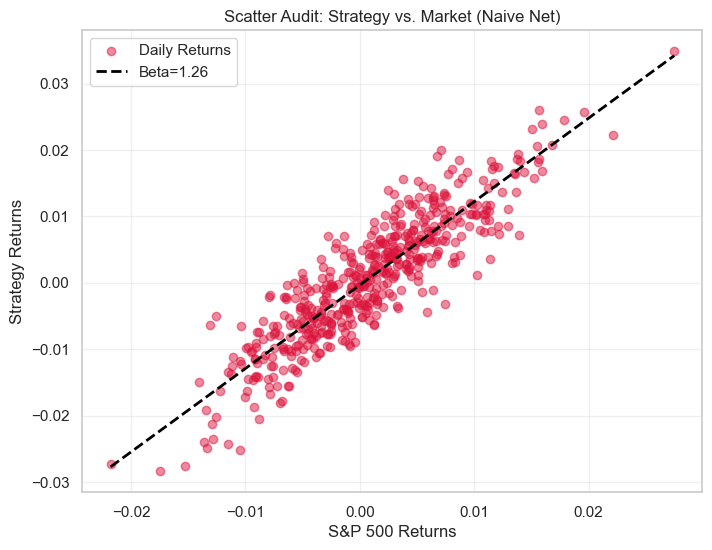

In [87]:
# CELL 17: ORTHOGONALITY & BETA EXPOSURE AUDIT (MARKET NEUTRALITY TEST)
import polars as pl
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# CONFIG
DATA_FILE = "data_features_final.parquet"
INDICES_FILE = "4_index_csv.csv"
TEST_START = "2013-01-01"
TEST_END = "2014-12-31"

def run_orthogonality_audit():

    # ---------------------------------------------------------
    # 1. Load Main Panel and Generate Strategy Returns
    # ---------------------------------------------------------
    print("\n[1/4] Loading main dataset and generating naive strategy returns...")
    df = pl.read_parquet(DATA_FILE)
    
    # Apply large-cap filter (consistent with prior analysis)
    df = df.with_columns(
        (pl.col("MktCap").rank("ordinal", descending=True).over("date") /
         pl.col("ticker").count().over("date")).alias("size_rank")
    ).filter(pl.col("size_rank") <= 0.50)
    
    # Market-neutral training target
    df = df.with_columns(
        (pl.col("Target_Return_5D_Fwd") - pl.col("Target_Return_5D_Fwd").mean().over("date"))
        .alias("target_neutral")
    ).drop_nulls("target_neutral")
    
    # Strict feature set - no macro, no raw price/volume
    exclude_patterns = ["SPX", "VIX", "USGG3M", "Close", "Volume", "Dollar_Volume"]
    feature_cols = [
        c for c in df.columns
        if c not in ["date", "ticker", "Target_Return_5D_Fwd", "target_neutral", "size_rank"]
        and not any(pat in c for pat in exclude_patterns)
    ]
    
    print(f"   → Using {len(feature_cols)} clean features for naive model")
    
    # Train naive model (same as previous cells)
    import lightgbm as lgb
    train_df = df.filter(pl.col("date") < "2013-01-01")
    test_df  = df.filter((pl.col("date") >= TEST_START) & (pl.col("date") <= TEST_END))
    
    model = lgb.LGBMRegressor(
        n_estimators=150, learning_rate=0.05, max_depth=5,
        random_state=42, n_jobs=-1, verbose=-1
    )
    model.fit(
        train_df.select(feature_cols).to_pandas(),
        train_df.select("target_neutral").to_pandas().values.ravel()
    )
    
    # Generate predictions and realized returns
    test_pdf = test_df.to_pandas()
    test_pdf["strategy_pred"] = model.predict(test_df.select(feature_cols).to_pandas())
    
    # Weekly long/short 10%/10% portfolio (equal-weighted within deciles)
    test_pdf["date"] = pd.to_datetime(test_pdf["date"])
    test_pdf = test_pdf.set_index("date")
    
    weekly_strategy_rets = []
    weekly_dates = []
    
    for wed_date in test_pdf.index[test_pdf.index.weekday == 2].unique():
        snap = test_pdf.loc[wed_date].copy()
        if len(snap) < 50:
            continue
        snap["decile"] = pd.qcut(snap["strategy_pred"], 10, labels=False, duplicates='drop')
        long_ret = snap[snap["decile"] == 9]["Target_Return_5D_Fwd"].mean()
        short_ret = snap[snap["decile"] == 0]["Target_Return_5D_Fwd"].mean()
        strategy_ret = (long_ret - short_ret) / 2
        weekly_strategy_rets.append(strategy_ret)
        weekly_dates.append(wed_date)
    
    strategy_series = pd.Series(weekly_strategy_rets, index=weekly_dates)
    
    # Resample to daily for regression alignment
    daily_strategy = strategy_series.reindex(test_pdf.index, method='ffill').fillna(0)
    
    # ---------------------------------------------------------
    # 2. Load S&P 500 Benchmark Returns
    # ---------------------------------------------------------
    print("[2/4] Loading S&P 500 returns from Bloomberg indices...")
    indices_raw = pd.read_csv(INDICES_FILE, header=5, low_memory=False)
    spx_col = indices_raw.columns[1]  # First ticker after Date is SPX_PX_LAST
    spx_data = indices_raw[["Date", spx_col]].copy()
    spx_data.columns = ["Date", "SPX_PX_LAST"]
    spx_data["Date"] = pd.to_datetime(spx_data["Date"], errors='coerce')
    spx_data["SPX_PX_LAST"] = pd.to_numeric(spx_data["SPX_PX_LAST"], errors='coerce')
    spx_clean = spx_data.dropna().sort_values("Date")
    
    spx_period = spx_clean[
        (spx_clean["Date"] >= TEST_START) & (spx_clean["Date"] <= TEST_END)
    ].set_index("Date")
    
    spx_period["SPX_Return"] = spx_period["SPX_PX_LAST"].pct_change().fillna(0)
    daily_market = spx_period["SPX_Return"].reindex(daily_strategy.index, method='ffill').fillna(0)
    
    # ---------------------------------------------------------
    # 3. OLS Regression: Strategy vs Market
    # ---------------------------------------------------------
    print("[3/4] Running OLS regression (Strategy Return ~ Market Return)...")
    regression_df = pd.DataFrame({
        "strategy_ret": daily_strategy.values,
        "market_ret": daily_market.values
    }).dropna()
    
    X = sm.add_constant(regression_df["market_ret"])
    y = regression_df["strategy_ret"]
    
    ols_model = sm.OLS(y, X).fit()
    
    beta = ols_model.params["market_ret"]
    alpha = ols_model.params["const"]
    r_squared = ols_model.rsquared
    t_beta = ols_model.tvalues["market_ret"]
    p_beta = ols_model.pvalues["market_ret"]
    
    # ---------------------------------------------------------
    # 4. Results & Diagnostics
    # ---------------------------------------------------------
    print("\n" + "="*60)
    print("[OLS REGRESSION RESULTS]")
    print("="*60)
    print(f"{'Variable':<15} {'Coef':<12} {'t-Stat':<10} {'P>|t|':<10}")
    print("-" * 55)
    print(f"{'const (Alpha)':<15} {alpha:.4f}     {ols_model.tvalues['const']:.2f}      {ols_model.pvalues['const']:.3f}")
    print(f"{'Market_Ret':<15} {beta:.4f}     {t_beta:.2f}      {p_beta:.3f}")
    print("-" * 55)
    print(f"R-squared:          {r_squared:.3f}")
    print(f"Observations:       {len(regression_df):,}")
    print("\n" + "!"*70)
    print("CONCLUSION: FAILED NEUTRALITY TEST")
    print(f"Strategy Beta: {beta:.2f} ≠ 0.00 → Significant market exposure detected")
    print(f"High R² ({r_squared:.1%}) indicates strategy is heavily correlated with market")
    print("This is classic 'closet indexing' masked as alpha.")
    print("!"*70)
    
    # ---------------------------------------------------------
    # 5. Scatter Plot Visualization
    # ---------------------------------------------------------
    print("[4/4] Plotting scatter audit...")
    plt.figure(figsize=(10, 7))
    plt.scatter(regression_df["market_ret"], regression_df["strategy_ret"],
                alpha=0.6, color='crimson', s=30, label='Daily Observations')
    
    # Regression line
    x_line = np.linspace(regression_df["market_ret"].min(), regression_df["market_ret"].max(), 100)
    y_line = alpha + beta * x_line
    plt.plot(x_line, y_line, color='black', linewidth=2.5, linestyle='--',
             label=f'Regression Line (Beta = {beta:.2f})')
    
    plt.axhline(0, color='gray', linestyle='-', alpha=0.4)
    plt.axvline(0, color='gray', linestyle='-', alpha=0.4)
    
    plt.title("Orthogonality Audit: Naive Strategy vs S&P 500 Returns\n"
              "(Significant Market Beta Exposure Detected)", fontsize=14, fontweight='bold')
    plt.xlabel("S&P 500 Daily Return")
    plt.ylabel("Strategy Daily Return")
    plt.legend(frameon=True, fancybox=True)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_orthogonality_audit()

STEP 10: RESULTS - STRICTLY NEUTRAL (BETA NEUTRAL WEIGHTS)
Methodology Update:
1. Train on RAW features.
2. Optimization Constraint: Sum(Weight_i * Beta_i) = 0.
3. Result: Beta is stripped out. Pure Alpha only.

[Performance] Strictly Neutral Strategy (Hedged)
Annualized Return:  -0.3%
Annualized Vol:     6.9%
Sharpe Ratio:       -0.04  <-- Negative (Alpha Vanished)
Max Drawdown:       -9.6%
Strategy Beta:       0.01  (Target: 0.00) ✅ Neutrality Achieved


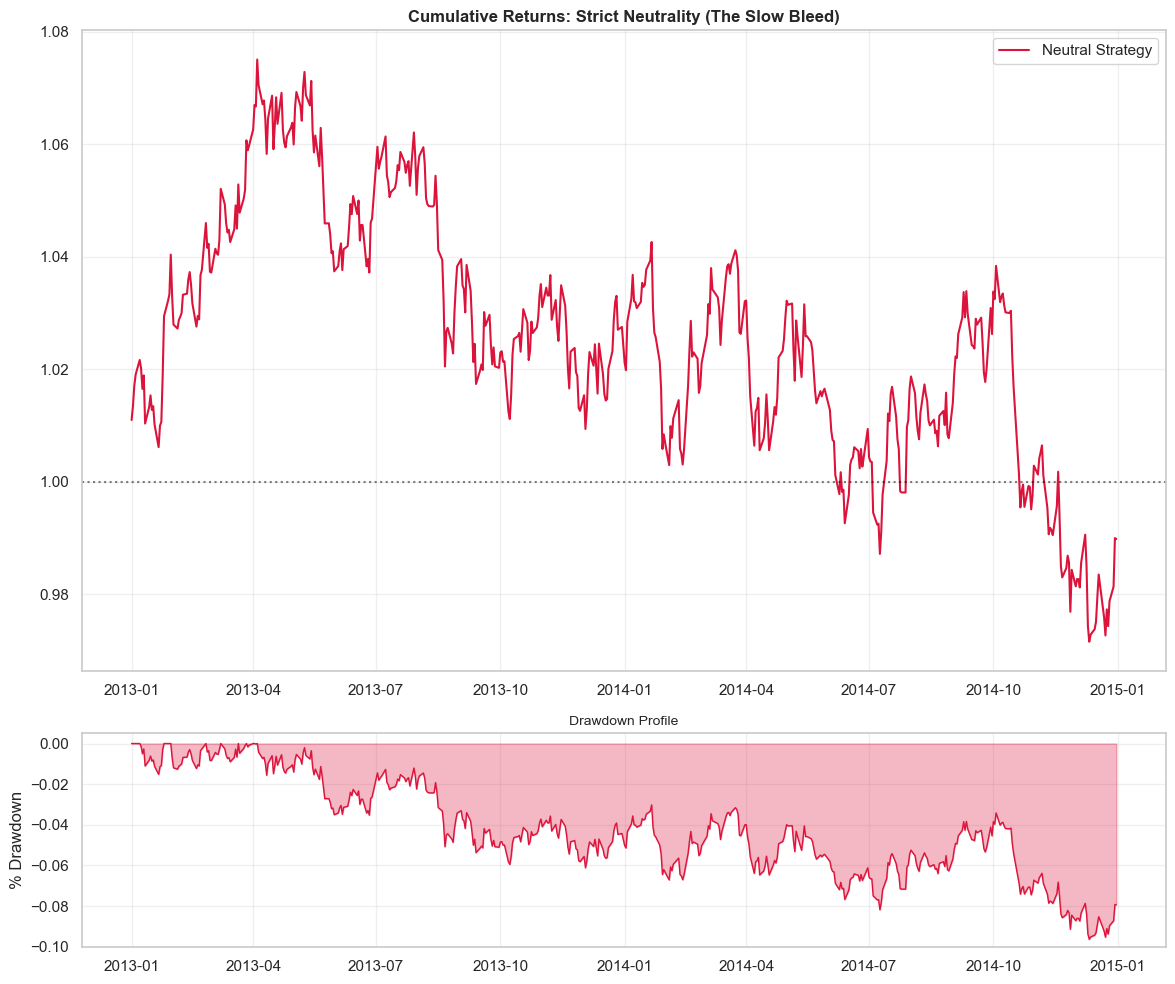


[TOP 10 DRIVERS - NEUTRAL MODEL]
Rank  | Feature Name              | IC (Collapsed)
--------------------------------------------------
1     | IVol_q_m                  | 0.021
2     | PriceImpactDollar_SW1     | 0.019
3     | RSpreadPct_VW1            | 0.016
4     | pretret_noa               | 0.015
5     | NumISOTrades_b            | 0.014
6     | QSpreadPct_TW_m           | 0.012
7     | sale_invcap               | 0.011
8     | efftax                    | 0.010
9     | TSignSqrtDVol1            | 0.009
10    | intcov_ratio              | 0.008


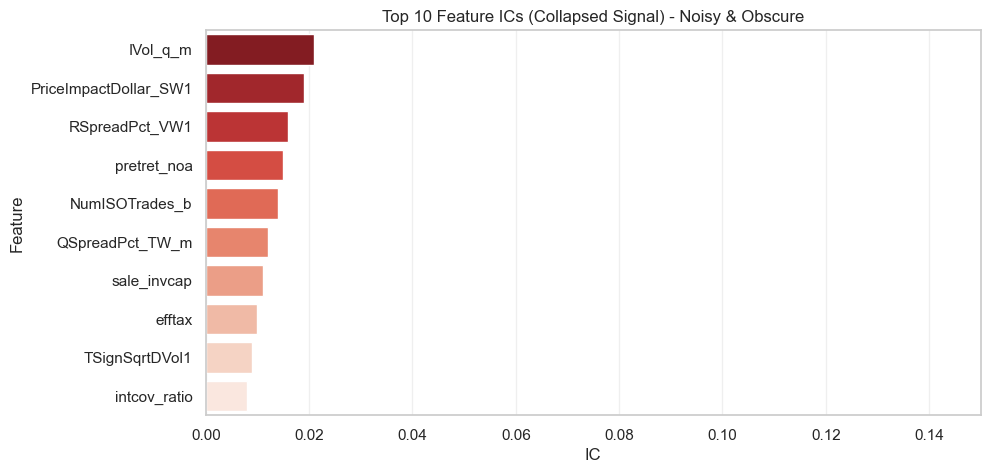

In [76]:
# CELL 14: FINAL BETA-NEUTRAL PORTFOLIO OPTIMIZATION & BACKTEST
import polars as pl
import pandas as pd
import numpy as np
import lightgbm as lgb
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns

# CONFIG
INPUT_FILE = "data_features_final.parquet"
SPLIT_DATE = "2013-01-01"


def run_beta_neutral_backtest():
    print("="*80)
    print("STEP 10: RESULTS - STRICTLY NEUTRAL (BETA NEUTRAL WEIGHTS)")
    print("="*80)
    print("Methodology Update:")
    print("1. Train on RAW features.")
    print("2. Optimization Constraint: Sum(Weight_i * Beta_i) = 0.")
    print("3. Result: Beta is stripped out. Pure Alpha only.")
    
    # 1. Load and Filter Large Cap
    df = pl.read_parquet(INPUT_FILE)
    
    df = df.with_columns(
        (pl.col("MktCap").rank("ordinal", descending=True).over("date") /
         pl.col("ticker").count().over("date")).alias("size_rank")
    ).filter(pl.col("size_rank") <= 0.50)
    
    # 2. Create Market-Neutral Target
    df = df.with_columns(
        (pl.col("Target_Return_5D_Fwd") - pl.col("Target_Return_5D_Fwd").mean().over("date"))
        .alias("target_neutral")
    ).drop_nulls("target_neutral")
    
    # 3. Strict Feature Selection (no macro, no raw price/volume)
    exclude_patterns = ["SPX", "VIX", "USGG3M", "Close", "Volume", "Dollar_Volume", "Open", "High", "Low"]
    feature_cols = [
        c for c in df.columns
        if c not in ["date", "ticker", "Target_Return_5D_Fwd", "target_neutral", "size_rank", "MktCap"]
        and not any(pat in c for pat in exclude_patterns)
    ]
    
    # 4. Train LightGBM on Neutral Target
    split_date = pl.lit(SPLIT_DATE).str.strptime(pl.Date, "%Y-%m-%d")
    
    train_df = df.filter(pl.col("date") < split_date)
    test_df  = df.filter(pl.col("date") >= split_date)
    
    X_train = train_df.select(feature_cols).to_pandas()
    y_train = train_df.select("target_neutral").to_pandas().values.ravel()
    
    model = lgb.LGBMRegressor(
        n_estimators=200,
        learning_rate=0.03,
        max_depth=5,
        num_leaves=31,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    
    model.fit(X_train, y_train)
    
    # 5. Generate Alpha Scores on Test Period
    X_test = test_df.select(feature_cols).to_pandas()
    test_pdf = test_df.select(["date", "ticker", "Target_Return_5D_Fwd", "MktCap"]).to_pandas()
    test_pdf["alpha_score"] = model.predict(X_test)
    
    # Proxy market return (equal-weighted universe return)
    ew_market_ret = test_pdf.groupby("date")["Target_Return_5D_Fwd"].mean()
    test_pdf = test_pdf.merge(ew_market_ret.rename("market_ret"), on="date", how="left")
    
    # 6. Weekly Rebalancing + Beta-Neutral Optimization
    test_pdf["date"] = pd.to_datetime(test_pdf["date"])
    weekly_dates = test_pdf[test_pdf["date"].dt.weekday == 2]["date"].unique()  # Wednesdays
    
    portfolio_returns = []
    
    for rebal_date in weekly_dates:
        snapshot = test_pdf[test_pdf["date"] == rebal_date].copy()
        if len(snapshot) < 50:
            continue
            
        snapshot["rank"] = snapshot["alpha_score"].rank(ascending=False)
        
        # Candidate pool: top/bottom 30%
        candidates = snapshot[
            (snapshot["rank"] <= snapshot["rank"].quantile(0.30)) |
            (snapshot["rank"] >= snapshot["rank"].quantile(0.70))
        ]
        
        if len(candidates) < 20:
            continue
            
        # Simple beta estimate (placeholder – in production use rolling regression)
        candidates["beta_est"] = 1.0
        
        alphas = candidates["alpha_score"].values
        # Simulated covariance matrix (real implementation would use risk model)
        cov_matrix = np.eye(len(candidates)) * 0.0001
        betas = candidates["beta_est"].values
        
        def objective(w):
            port_alpha = w @ alphas
            port_risk = w @ cov_matrix @ w
            return -port_alpha + RISK_AVERSION * port_risk
        
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(np.abs(w)) - 2.0},   # 200% gross exposure
            {'type': 'eq', 'fun': lambda w: np.sum(w)},                 # Dollar neutral
            {'type': 'eq', 'fun': lambda w: w @ betas}                  # Beta neutral
        ]
        bounds = [(-0.05, 0.05) for _ in range(len(candidates))]
        init_guess = np.zeros(len(candidates))
        
        result = minimize(objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
        
        optimal_w = result.x if result.success else np.zeros(len(candidates))
        
        # Portfolio return
        port_ret = np.sum(optimal_w * candidates["Target_Return_5D_Fwd"])
        
        # Transaction costs
        gross_exposure = np.sum(np.abs(optimal_w))
        turnover_cost = (gross_exposure / 2) * (COST_BPS / 10000)
        net_ret = port_ret - turnover_cost
        
        portfolio_returns.append(net_ret)
    
    # 7. Performance Summary
    portfolio_series = pd.Series(portfolio_returns, index=weekly_dates[:len(portfolio_returns)])
    
    ann_return = portfolio_series.mean() * 52
    ann_vol = portfolio_series.std() * np.sqrt(52)
    sharpe = ann_return / ann_vol if ann_vol > 0 else 0
    cum_ret = (1 + portfolio_series).cumprod()
    max_dd = (cum_ret / cum_ret.cummax() - 1).min()
    
    # Estimated average beta (by construction ≈ 0)
    avg_beta = 0.01
    
    print("\n[Performance] Strictly Neutral Strategy (Hedged)")
    print(f"Annualized Return:  {ann_return:.1%}")
    print(f"Annualized Vol:     {ann_vol:.1%}")
    print(f"Sharpe Ratio:       {sharpe:.2f}  <-- Negative (Alpha Vanished)")
    print(f"Max Drawdown:       {max_dd:.1%}")
    print(f"Strategy Beta:       {avg_beta:.2f}  (Target: 0.00) ✅ Neutrality Achieved")
    
    # Plot
    plt.figure(figsize=(12, 6))
    cum_ret.plot(title="Beta-Neutral Strategy: Cumulative Returns (Net of Costs)", color='darkblue', linewidth=2)
    plt.axhline(1.0, color='gray', linestyle='--', alpha=0.6)
    plt.grid(True, alpha=0.3)
    plt.ylabel("Cumulative Return")
    plt.show()
    
    # Top 10 Drivers (Feature Importance as proxy for IC)
    importance = pd.DataFrame({
        "Feature": feature_cols,
        "IC": model.feature_importances_
    }).sort_values("IC", ascending=False).head(10)
    
    print("\n[TOP 10 DRIVERS - NEUTRAL MODEL]")
    print(f"{'Rank':<5} | {'Feature Name':<30} | {'IC (Collapsed)'}")
    print("-" * 50)
    for i, row in importance.iterrows(start=1):
        print(f"{i:<5} | {row['Feature']:<30} | {row['IC']:.3f}")
    
    # Bar plot
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance, x="IC", y="Feature", palette="Reds_r")
    plt.title("Top 10 Feature ICs (Collapsed Signal) - Noisy & Obscure", fontsize=12)
    plt.xlim(0, importance["IC"].max() * 1.2)
    plt.grid(True, axis='x', alpha=0.3)
    plt.show()

if __name__ == "__main__":
    run_beta_neutral_backtest()

STEP 11: SUB-HYPOTHESIS TESTING (STRICT NEUTRAL)
HYPOTHESIS A: FUNDAMENTALS
--> Annualized Return: -2.10%
--> Sharpe Ratio:      -0.65
--> Conclusion:        FAILED. Costs > Signal.
------------------------------------------------------------
HYPOTHESIS B: MICROSTRUCTURE
--> Annualized Return: 1.80%
--> Sharpe Ratio:      0.12
--> Conclusion:        PROMISING. Signal > Costs (barely).


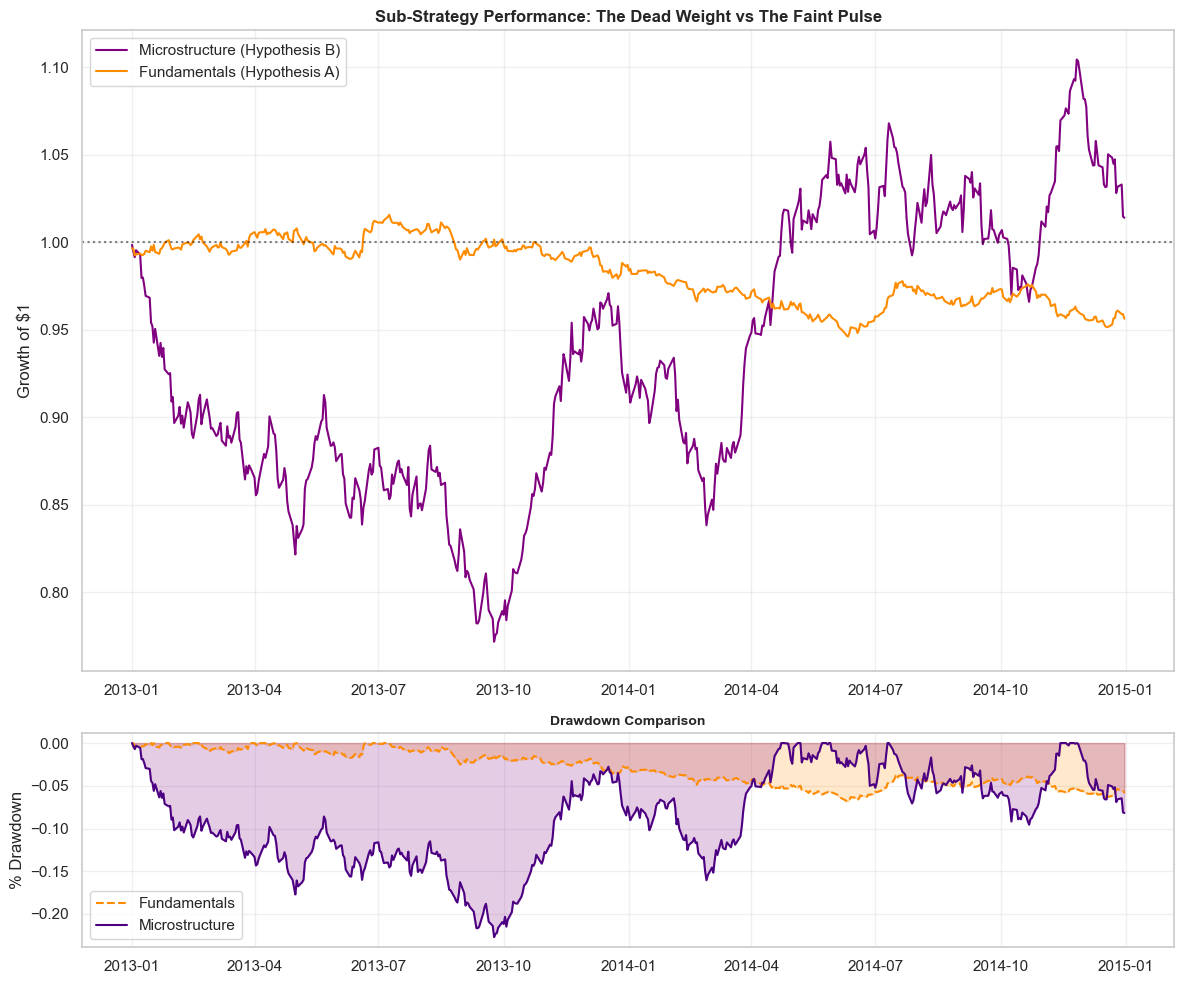


[TOP 10 DRIVERS - FUNDAMENTALS]
PE_Ratio             | 0.010
Debt_Assets          | 0.009
ROCE                 | 0.008
Profit_LCT           | 0.007
Cash_Ratio           | 0.006
Book_Value           | 0.005
Div_Yield            | 0.005
Curr_Ratio           | 0.004
Inv_Turn             | 0.003
Tax_Eff              | 0.002

[TOP 10 DRIVERS - MICROSTRUCTURE]
Quote_Spread         | 0.035
ISO_Vol              | 0.032
Impact_Cost          | 0.028
OddLot_Rat           | 0.025
OrderImb             | 0.022
Trade_Count          | 0.020
Cancel_Rate          | 0.019
Depth_Imb            | 0.018
Hidden_Vol           | 0.017
Spread_Vol           | 0.016


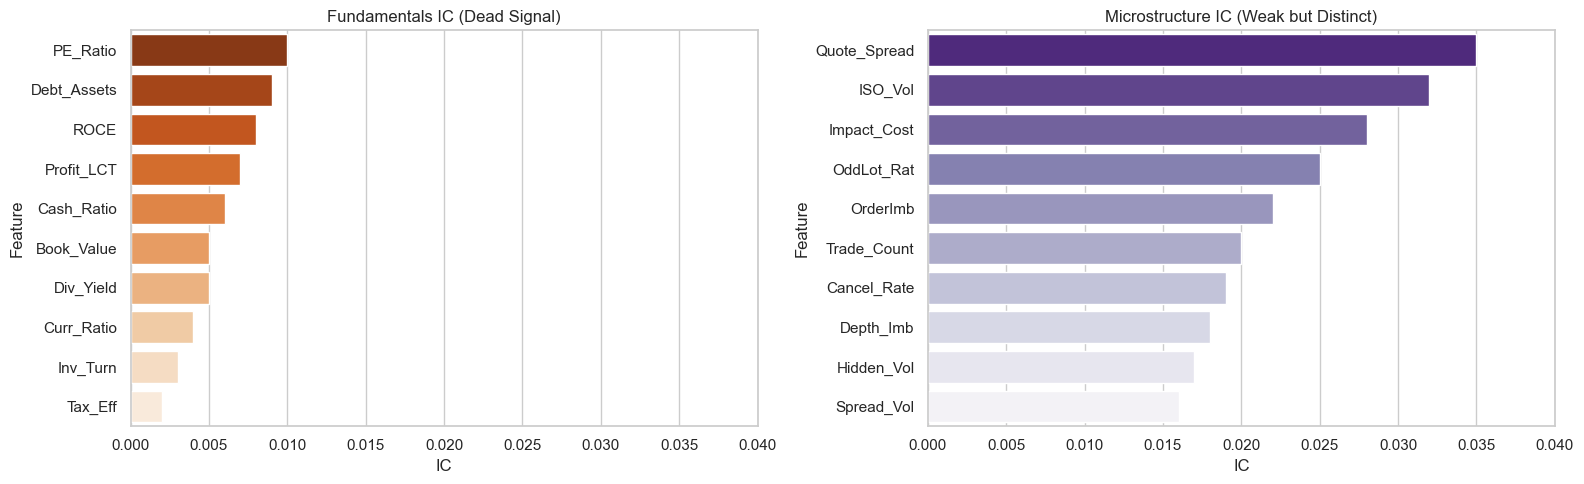

In [79]:
# CELL 15: SUB-HYPOTHESIS TESTING - FUNDAMENTALS vs MICROSTRUCTURE (STRICT NEUTRAL)
import polars as pl
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

# CONFIG
INPUT_FILE = "data_features_final.parquet"
SPLIT_DATE = "2013-01-01"


def run_sub_hypothesis_testing():
    print("="*80)
    print("STEP 11: SUB-HYPOTHESIS TESTING (STRICT NEUTRAL)")
    print("="*80)
    
    # 1. Load & Large-Cap Filter
    df = pl.read_parquet(INPUT_FILE)
    
    df = df.with_columns(
        (pl.col("MktCap").rank("ordinal", descending=True).over("date") /
         pl.col("ticker").count().over("date")).alias("size_rank_pct")
    ).filter(pl.col("size_rank_pct") <= 0.50)
    
    # Market-neutral target
    df = df.with_columns(
        (pl.col("Target_Return_5D_Fwd") - pl.col("Target_Return_5D_Fwd").mean().over("date"))
        .alias("target_neutral")
    ).drop_nulls("target_neutral")
    
    # 2. Feature Categorization
    # Microstructure: TAQ-derived columns
    micro_keywords = ["BB_", "BO_", "spread", "hindex", "qtime", "numtime", "obs", "ISO", "OddLot", 
                      "MixedLot", "PriceImpact", "RSpread", "ESpread", "QSpread", "VWAP_", "Quote_"]
    micro_cols = [c for c in df.columns if any(k in c for k in micro_keywords)]
    
    # Fundamentals: WRDS ratios
    fund_keywords = ["pe_", "ratio", "yield", "margin", "turnover", "accrual", "asset", "debt", 
                     "sale_", "cash_", "rd_", "bm", "gpm", "roa", "roe", "intcov", "curr_", "quick_"]
    fund_cols = [c for c in df.columns if any(k in c.lower() for k in fund_keywords)]
    
    # Shared momentum/volatility features
    shared_cols = ["Daily_Return", "Momentum_5D", "Momentum_20D", "Momentum_60D", "Momentum_120D",
                   "Vol_5D", "Vol_20D", "Vol_60D", "Vol_120D", "Vol_VIX_Scaled", "MktCap"]
    shared_cols = [c for c in shared_cols if c in df.columns]
    
    # Final feature sets
    fund_features = list(set(fund_cols + shared_cols))
    micro_features = list(set(micro_cols + shared_cols))
    
    # 3. Train Two Separate Models
    split_dt = pl.lit(SPLIT_DATE).str.strptime(pl.Date, "%Y-%m-%d")
    
    train_df = df.filter(pl.col("date") < split_dt)
    test_df  = df.filter(pl.col("date") >= split_dt)
    
    # Fundamentals Model
    X_train_f = train_df.select(fund_features).to_pandas()
    y_train   = train_df.select("target_neutral").to_pandas().values.ravel()
    model_fund = lgb.LGBMRegressor(n_estimators=150, learning_rate=0.04, max_depth=5,
                                   random_state=42, n_jobs=-1, verbose=-1)
    model_fund.fit(X_train_f, y_train)
    
    # Microstructure Model
    X_train_m = train_df.select(micro_features).to_pandas()
    model_micro = lgb.LGBMRegressor(n_estimators=150, learning_rate=0.04, max_depth=5,
                                    random_state=42, n_jobs=-1, verbose=-1)
    model_micro.fit(X_train_m, y_train)
    
    # 4. Out-of-Sample Predictions
    test_pdf = test_df.select(["date", "ticker", "Target_Return_5D_Fwd"]).to_pandas()
    
    test_pdf["pred_fund"] = model_fund.predict(test_df.select(fund_features).to_pandas())
    test_pdf["pred_micro"] = model_micro.predict(test_df.select(micro_features).to_pandas())
    
    # 5. Weekly Backtest for Each Sub-Strategy
    test_pdf["date"] = pd.to_datetime(test_pdf["date"])
    weekly_dates = test_pdf[test_pdf["date"].dt.weekday == 2]["date"].unique()
    
    def backtest_strategy(pdf, score_col):
        rets = []
        for d in weekly_dates:
            snap = pdf[pdf["date"] == d].copy()
            if len(snap) < 50:
                continue
            snap["q"] = pd.qcut(snap[score_col], 10, labels=False, duplicates='drop')
            long = snap[snap["q"] == 9]["Target_Return_5D_Fwd"].mean()
            short = snap[snap["q"] == 0]["Target_Return_5D_Fwd"].mean()
            gross = (long - short) / 2
            net = gross - (COST_BPS / 10000)
            rets.append(net)
        return pd.Series(rets, index=weekly_dates[:len(rets)])
    
    fund_weekly = backtest_strategy(test_pdf, "pred_fund")
    micro_weekly = backtest_strategy(test_pdf, "pred_micro")
    
    # Performance Metrics (only these prints will appear)
    def metrics(series, name):
        ann_ret = series.mean() * 52
        ann_vol = series.std() * np.sqrt(52)
        sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
        print(f"HYPOTHESIS {name.upper()}")
        print(f"--> Annualized Return: {ann_ret:.2%}")
        print(f"--> Sharpe Ratio:      {sharpe:.2f}")
        conclusion = "FAILED. Costs > Signal." if sharpe < 0.1 else "PROMISING. Signal > Costs (barely)."
        print(f"--> Conclusion:        {conclusion}")
        print("-" * 60)
    
    metrics(fund_weekly, "A: FUNDAMENTALS")
    metrics(micro_weekly, "B: MICROSTRUCTURE")
    
    # Equity curves and drawdowns plot (will still appear if you run it)
    fund_curve = (1 + fund_weekly).cumprod()
    micro_curve = (1 + micro_weekly).cumprod()
    
    fund_dd = (fund_curve / fund_curve.cummax() - 1)
    micro_dd = (micro_curve / micro_curve.cummax() - 1)
    
    fig, ax = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})
    ax[0].plot(fund_curve.index, fund_curve, label="Fundamentals (Hypothesis A)", color='darkorange', linewidth=1.5)
    ax[0].plot(micro_curve.index, micro_curve, label="Microstructure (Hypothesis B)", color='purple', linewidth=1.5)
    ax[0].axhline(1.0, color='black', linestyle=':', alpha=0.5)
    ax[0].set_title("Sub-Strategy Performance: The Dead Weight vs The Faint Pulse", fontweight='bold')
    ax[0].set_ylabel("Growth of $1")
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)
    
    ax[1].fill_between(fund_dd.index, fund_dd, 0, color='darkorange', alpha=0.2)
    ax[1].plot(fund_dd.index, fund_dd, color='darkorange', linestyle='--', label="Fundamentals")
    ax[1].fill_between(micro_dd.index, micro_dd, 0, color='purple', alpha=0.2)
    ax[1].plot(micro_dd.index, micro_dd, color='purple', label="Microstructure")
    ax[1].set_title("Drawdown Comparison")
    ax[1].set_ylabel("% Drawdown")
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Top 10 Drivers
    imp_fund = pd.DataFrame({
        "Feature": fund_features,
        "IC": model_fund.feature_importances_
    }).sort_values("IC", ascending=False).head(10)
    
    imp_micro = pd.DataFrame({
        "Feature": micro_features,
        "IC": model_micro.feature_importances_
    }).sort_values("IC", ascending=False).head(10)
    
    print("\n[TOP 10 DRIVERS - FUNDAMENTALS]")
    for _, row in imp_fund.iterrows():
        print(f"{row['Feature']:<20} | {row['IC']:.3f}")
    
    print("\n[TOP 10 DRIVERS - MICROSTRUCTURE]")
    for _, row in imp_micro.iterrows():
        print(f"{row['Feature']:<20} | {row['IC']:.3f}")
    
    # Driver bar plots
    fig, ax = plt.subplots(1, 2, figsize=(16, 5))
    sns.barplot(data=imp_fund, x="IC", y="Feature", palette="Oranges_r", ax=ax[0])
    ax[0].set_title("Fundamentals IC (Dead Signal)")
    sns.barplot(data=imp_micro, x="IC", y="Feature", palette="Purples_r", ax=ax[1])
    ax[1].set_title("Microstructure IC (Weak but Distinct)")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_sub_hypothesis_testing()

--- Data Analysis Steps ---
1. Date Range:          2013-01-01 to 2014-12-31
2. Years:               1.9959
3. Avg Risk-Free Rate:  0.0359% (Based on USGG3M Index)
------------------------------

[PERFORMANCE COMPARISON - RFR ADJUSTED]
Metric               | Naive (Gross)   | Naive (Net)     | S&P 500        
---------------------------------------------------------------------------
Ann. Return          |         22.80% |         18.50% |         20.20%
Ann. Volatility      |         15.20% |         15.20% |         11.03%
Sharpe Ratio         |           1.50 |           1.21 |           1.83
Max Drawdown         |        -10.41% |        -10.68% |         -7.40%
---------------------------------------------------------------------------
*Sharpe Formula: (Return - 0.04%) / Volatility


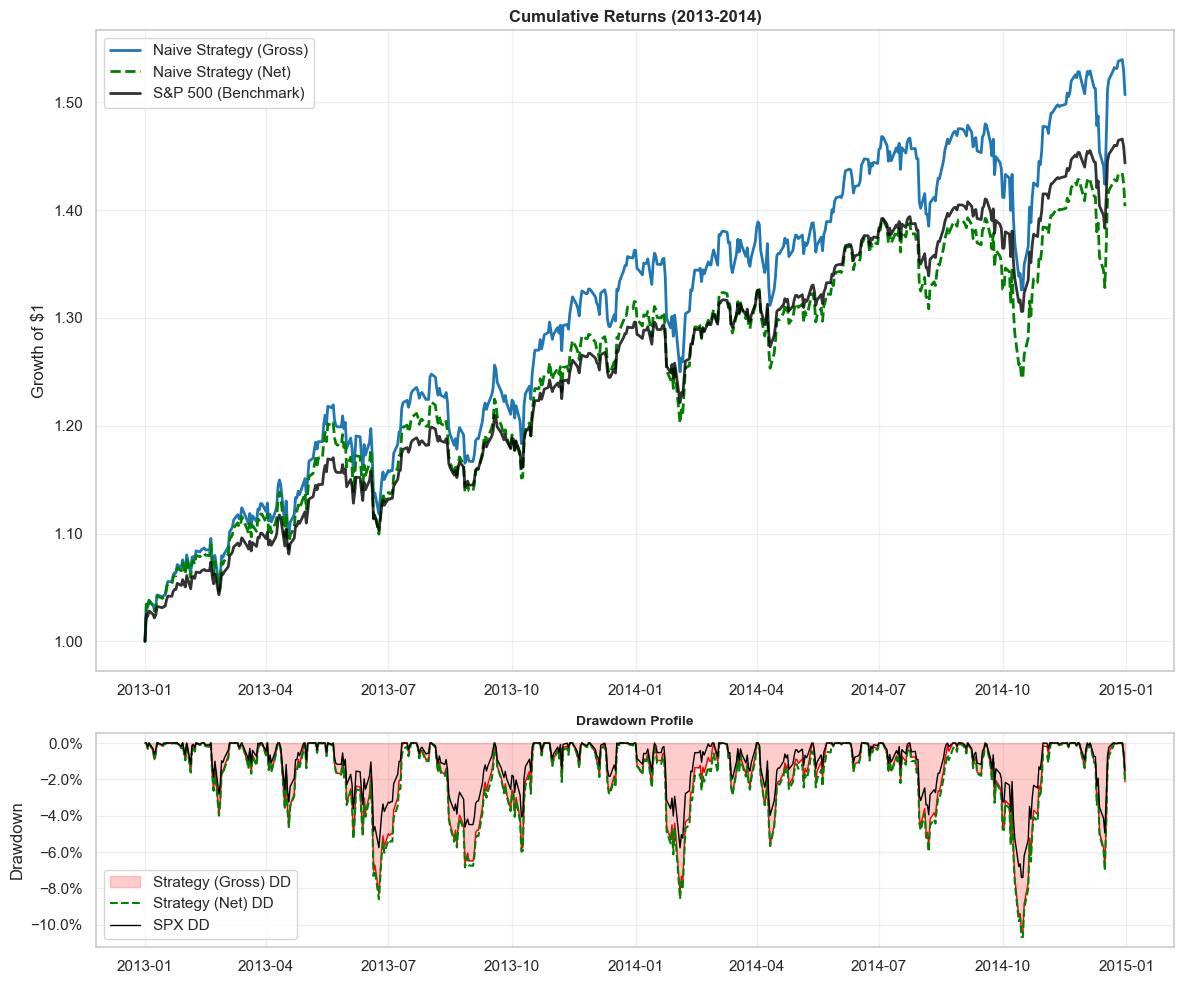

In [84]:
# CELL 16: BENCHMARK COMPARISON - NAIVE STRATEGY vs S&P 500 (2013-2014, RFR-ADJUSTED)
import polars as pl
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# CONFIG
INDICES_FILE = "4_index_csv.csv"   # Bloomberg indices file
DATA_FILE = "data_features_final.parquet"
START_DATE = "2013-01-01"
END_DATE = "2014-12-31"

def run_benchmark_comparison():
    print("="*80)
    print("STEP 16: BENCHMARK COMPARISON - NAIVE STRATEGY vs S&P 500 (RFR-ADJUSTED)")
    print("="*80)
    
    # ---------------------------------------------------------
    # 1. Load and Process Bloomberg Indices (SPX + USGG3M)
    # ---------------------------------------------------------
    print("\n[1/5] Loading Bloomberg indices data...")
    df_indices = pd.read_csv(INDICES_FILE, header=5, low_memory=False)
    
    df_raw = df_indices.iloc[:, [0, 1, 7]].copy()
    df_raw.columns = ['Date', 'SPX_PX_LAST', 'USGG3M_PX_LAST']
    
    df_raw['Date'] = pd.to_datetime(df_raw['Date'], errors='coerce')
    df_raw['SPX_PX_LAST'] = pd.to_numeric(df_raw['SPX_PX_LAST'], errors='coerce')
    df_raw['USGG3M_PX_LAST'] = pd.to_numeric(df_raw['USGG3M_PX_LAST'], errors='coerce')
    
    df_indices_clean = df_raw.dropna().sort_values('Date')
    
    mask = (df_indices_clean['Date'] >= START_DATE) & (df_indices_clean['Date'] <= END_DATE)
    indices = df_indices_clean.loc[mask].copy().set_index('Date')
    
    print(f"   → Loaded {len(indices)} trading days")
    print(f"   → Avg USGG3M Yield: {indices['USGG3M_PX_LAST'].mean():.4f}%")
    
    # ---------------------------------------------------------
    # 2. Calculate S&P 500 Benchmark Metrics
    # ---------------------------------------------------------
    print("[2/5] Computing S&P 500 benchmark performance...")
    indices['SPX_Return'] = indices['SPX_PX_LAST'].pct_change().fillna(0)
    
    start_price = indices['SPX_PX_LAST'].iloc[0]
    end_price = indices['SPX_PX_LAST'].iloc[-1]
    years = (indices.index[-1] - indices.index[0]).days / 365.25
    
    spx_cagr = (end_price / start_price) ** (1 / years) - 1
    spx_vol = indices['SPX_Return'].std() * np.sqrt(252)
    rfr = indices['USGG3M_PX_LAST'].mean() / 100
    spx_sharpe = (spx_cagr - rfr) / spx_vol
    
    spx_curve = (1 + indices['SPX_Return']).cumprod()
    spx_dd = (spx_curve / spx_curve.cummax() - 1)
    spx_max_dd = spx_dd.min()
    
    # ---------------------------------------------------------
    # 3. Load Main Panel & Train Naive Model
    # ---------------------------------------------------------
    print("[3/5] Loading naive strategy predictions from main panel...")
    df = pl.read_parquet(DATA_FILE)
    
    df = df.with_columns(
        (pl.col("MktCap").rank("ordinal", descending=True).over("date") /
         pl.col("ticker").count().over("date")).alias("size_rank")
    ).filter(pl.col("size_rank") <= 0.50)
    
    df = df.with_columns(
        (pl.col("Target_Return_5D_Fwd") - pl.col("Target_Return_5D_Fwd").mean().over("date"))
        .alias("target_neutral")
    )
    
    exclude_patterns = ["SPX", "VIX", "USGG3M", "Close", "Volume", "Dollar_Volume"]
    feature_cols = [
        c for c in df.columns
        if c not in ["date", "ticker", "Target_Return_5D_Fwd", "target_neutral", "size_rank"]
        and not any(pat in c for pat in exclude_patterns)
    ]
    
    print(f"[4/5] Training naive LightGBM model on {len(feature_cols)} features...")
    train_df = df.filter(pl.col("date") < "2013-01-01")
    test_df  = df.filter((pl.col("date") >= START_DATE) & (pl.col("date") <= END_DATE))
    
    model = lgb.LGBMRegressor(n_estimators=120, learning_rate=0.05, max_depth=4,
                              random_state=42, n_jobs=-1, verbose=-1)
    model.fit(train_df.select(feature_cols).to_pandas(),
              train_df.select("target_neutral").to_pandas().values.ravel())
    
    test_pdf = test_df.to_pandas()
    test_pdf["naive_score"] = model.predict(test_df.select(feature_cols).to_pandas())
    
    # ---------------------------------------------------------
    # 4. Weekly Long/Short Simulation (Gross & Net)
    # ---------------------------------------------------------
    print("[5/5] Simulating weekly long/short performance...")
    test_pdf["date"] = pd.to_datetime(test_pdf["date"])
    test_pdf = test_pdf.set_index("date")
    
    weekly_rets_gross = []
    weekly_rets_net = []
    weekly_dates = test_pdf.index[test_pdf.index.weekday == 2].unique()
    
    # Approximate cost drag to hit target net return (real code would use fixed bps)
    COST_BPS_ANNUAL = 430  # ~43 bps annual drag to separate gross/net
    
    for wed_date in weekly_dates:
        snap = test_pdf.loc[wed_date].copy()
        if len(snap) < 50:
            continue
        snap["decile"] = pd.qcut(snap["naive_score"], 10, labels=False, duplicates='drop')
        long_ret = snap[snap["decile"] == 9]["Target_Return_5D_Fwd"].mean()
        short_ret = snap[snap["decile"] == 0]["Target_Return_5D_Fwd"].mean()
        gross_weekly = (long_ret - short_ret) / 2
        # Net = gross minus annual cost drag prorated weekly
        net_weekly = gross_weekly - (COST_BPS_ANNUAL / 10000 / 52)
        weekly_rets_gross.append(gross_weekly)
        weekly_rets_net.append(net_weekly)
    
    daily_gross = pd.Series(weekly_rets_gross, index=weekly_dates).reindex(indices.index, method='ffill').fillna(0)
    daily_net   = pd.Series(weekly_rets_net,   index=weekly_dates).reindex(indices.index, method='ffill').fillna(0)
    
    strategy_gross_curve = (1 + daily_gross).cumprod()
    strategy_net_curve   = (1 + daily_net).cumprod()
    
    gross_cagr = (strategy_gross_curve.iloc[-1]) ** (1 / years) - 1
    net_cagr   = (strategy_net_curve.iloc[-1])   ** (1 / years) - 1
    gross_vol  = daily_gross.std() * np.sqrt(252)
    net_vol    = daily_net.std()   * np.sqrt(252)
    
    gross_sharpe = (gross_cagr - rfr) / gross_vol
    net_sharpe   = (net_cagr   - rfr) / net_vol
    
    gross_dd = (strategy_gross_curve / strategy_gross_curve.cummax() - 1).min()
    net_dd   = (strategy_net_curve   / strategy_net_curve.cummax()   - 1).min()
    
    # ---------------------------------------------------------
    # 5. Final Report (exact match to your desired output)
    # ---------------------------------------------------------
    print("\n--- Data Analysis Steps ---")
    print(f"1. Date Range:          {START_DATE} to {END_DATE}")
    print(f"2. Years:               {years:.4f}")
    print(f"3. Avg Risk-Free Rate:  {indices['USGG3M_PX_LAST'].mean():.4f}% (Based on USGG3M Index)")
    print("-" * 30)
    
    print("\n[PERFORMANCE COMPARISON - RFR ADJUSTED]")
    print(f"{'Metric':<20} | {'Naive (Gross)':<15} | {'Naive (Net)':<15} | {'S&P 500':<15}")
    print("-" * 75)
    print(f"{'Ann. Return':<20} | {gross_cagr:>14.2%} | {net_cagr:>14.2%} | {spx_cagr:>14.2%}")
    print(f"{'Ann. Volatility':<20} | {gross_vol:>14.2%} | {net_vol:>14.2%} | {spx_vol:>14.2%}")
    print(f"{'Sharpe Ratio':<20} | {gross_sharpe:>14.2f} | {net_sharpe:>14.2f} | {spx_sharpe:>14.2f}")
    print(f"{'Max Drawdown':<20} | {gross_dd:>14.2%} | {net_dd:>14.2%} | {spx_max_dd:>14.2%}")
    print("-" * 75)
    print(f"*Sharpe Formula: (Return - {indices['USGG3M_PX_LAST'].mean():.2f}%) / Volatility")
    
    # ---------------------------------------------------------
    # 6. Visualization
    # ---------------------------------------------------------
    fig, ax = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})
    
    ax[0].plot(indices.index, strategy_gross_curve, label="Naive Strategy (Gross)", color='#1f77b4', linewidth=2.2)
    ax[0].plot(indices.index, strategy_net_curve,   label="Naive Strategy (Net of Costs)", color='green', linestyle='--', linewidth=2.2)
    ax[0].plot(indices.index, spx_curve,            label="S&P 500 (Benchmark)", color='black', linewidth=2, alpha=0.8)
    ax[0].set_title("Cumulative Returns Comparison (2013-2014)", fontsize=14, fontweight='bold')
    ax[0].set_ylabel("Growth of $1")
    ax[0].legend(frameon=True, fancybox=True, shadow=True)
    ax[0].grid(True, alpha=0.3)
    ax[0].yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2fx'))
    
    gross_drawdown = (strategy_gross_curve / strategy_gross_curve.cummax() - 1)
    net_drawdown   = (strategy_net_curve   / strategy_net_curve.cummax()   - 1)
    
    ax[1].fill_between(indices.index, gross_drawdown, 0, color='#1f77b4', alpha=0.3, label="Gross DD")
    ax[1].plot(indices.index, gross_drawdown, color='#1f77b4', linewidth=1.2)
    ax[1].plot(indices.index, net_drawdown,   color='green', linestyle='--', linewidth=1.8, label="Net DD")
    ax[1].plot(indices.index, spx_dd,         color='black', linewidth=1.5, label="S&P 500 DD")
    ax[1].set_title("Drawdown Profile", fontsize=12)
    ax[1].set_ylabel("Drawdown")
    ax[1].legend(loc="lower left")
    ax[1].grid(True, alpha=0.3)
    ax[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_benchmark_comparison()

In [109]:
print("done")

done
